# BDT

This Jupyter Notebook contains the BDT used for separating the muon neutrino and muon anti-neutrino in the mixed sample containing $\nu_{\mu} + \bar{\nu}_{\mu}$. 

Input taking the .hdr5 files containing the Pandas dataframes for the selected sample.

### Input, importing the selected sample stored into .hdr5 file

In [1]:
#====================#
#  Import Packages   #
#====================#

import math 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.patches as mpatches
import mpltern

import uproot3 as uproot

# BDT
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, recall_score, precision_score, average_precision_score, precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import xgboost as xgb
import shap
from matplotlib.pylab import rcParams
import plotly.express as px
import seaborn as sns
from iminuit import Minuit
import ROOT
from tqdm import tqdm

import os
dfs_dir = "/scratch/wwang/dfs"
#%run numuNumubarSelection_run3b.ipynb 

/home/s2106059/nu_mu_xsec/.venv/lib64/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/home/s2106059/nu_mu_xsec/.venv/lib64/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "
TClassTable::Add:0: RuntimeWarning: class reverse_iterator<__gnu_cxx::__normal_iterator<TString*,vector<TString> > > already in TClassTable
TClassTable::Add:0: RuntimeWarning: class reverse_iterator<__gnu_cxx::__normal_iterator<string*,vector<string> > > already in TClassTable
TClassTable::A

In [2]:
lock1 = True
if lock1 == True:
    df_mcFC_FHC = pd.read_pickle(os.path.join(dfs_dir, 'df_mcFC_FHC.pkl'))
    df_dataFC_FHC = pd.read_pickle(os.path.join(dfs_dir, 'df_dataFC_FHC.pkl'))
    df_dirtFC_FHC = pd.read_pickle(os.path.join(dfs_dir, 'df_dirtFC_FHC.pkl'))
    df_extFC_FHC = pd.read_pickle(os.path.join(dfs_dir, 'df_extFC_FHC.pkl'))

In [3]:
#==================================#
# Auxiliary functions used for BDT #
#==================================#


def label_signal(df_):
    # this function labels the sample, =1 for signal (numuCC events), and =0 for background (otherwise) # flip definition
      
    condition_numubar = (df_['truth_nuPdg']==-14)
    condition_numu = (df_['truth_nuPdg']==14)
    condition_cc = (df_['truth_isCC']==1)

    condition_not_numubar = (df_['truth_nuPdg']!=-14)
    condition_not_numu = (df_['truth_nuPdg']!=14)
    condition_not_cc = (df_['truth_isCC']!=1)

    condition_not_allNumu_reco = (df_['numu_cc_flag']<1)
    
    query_numubarcc = condition_numubar & condition_cc
    query_numucc = condition_numu & condition_cc
    query_others = ~(query_numucc | query_numubarcc)

    df_numucc_init = df_[(query_numucc)]
    df_numubarcc_init = df_[(query_numubarcc)]
    df_others_init = df_.drop(df_numucc_init.index, errors='ignore').drop(df_numubarcc_init.index, errors='ignore')
    totalEvents = len(df_numucc_init) + len(df_numubarcc_init) + len(df_others_init)
    
    df_["bdt_numubarcc_label"] = df_.apply(lambda row:1 if query_numubarcc[row.name] else 0, axis=1)
    df_["bdt_numucc_label"] = df_.apply(lambda row:1 if query_numucc[row.name] else 0, axis=1)
    df_["bdt_others_label"] = df_.apply(lambda row:1 if query_others[row.name] else 0, axis=1)

    # for multivariate adaboost, need 1 labeling
    # df_["bdt_multi_label"] = df_.apply(lambda row:2 if query_numubarcc[row.name] else (1 if query_numucc[row.name] else 0) , axis=1)

    df_["bdt_multi_label"] = 0
    df_.loc[query_numucc, "bdt_multi_label"] = 1
    df_.loc[query_numubarcc, "bdt_multi_label"] = 2

    #Calculate the percentage of 1's
    percentage_signal_numu = (len(df_numucc_init) / totalEvents) * 100
    print(f"Labelled dataset. Portion of signal numuCC events in this sample: {percentage_signal_numu:.2f}%")
    
    percentage_signal_numubar = (len(df_numubarcc_init) / totalEvents) * 100
    print(f"Labelled dataset. Portion of signal numubarCC events in this sample: {percentage_signal_numubar:.2f}%")

    percentage_others = (len(df_others_init) / totalEvents) * 100
    print(f"Labelled dataset. Portion of background events in this sample: {percentage_others:.2f}%")
    
def remove_background_events(df_):
    # remove any event that is not nueCC/nuebarCC
    query = "(truth_nuPdg==14 | truth_nuPdg==-14) & truth_isCC==1"
    num_events_before = len(df_)
    df_.query(query, inplace=True) # keep only events where query=True
    contaminant_contribution = (num_events_before - len(df_))/num_events_before
    print(f"Removed {num_events_before - len(df_)} contaminants from the selection sample. This"
          f" constitutes {contaminant_contribution:.2%} of the sample.")
    
# For Python/C++ consistency:
# XGBoost can handle NaN internally, but the exported TMVA/C++ XML does not
# reliably preserve XGBoost's learned missing-value direction.
# Therefore we explicitly map NaN/inf values to -999 before both training
# and later BDT application.
def prepare_bdt_features(df, training_variables):
    return (
        df[training_variables]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(-999)
    )

## BDT Training for MC (Development sample)

In [4]:
# Rename dataframe, allowing df_bdt to be other things in the future.
# This is the full FHC MC overlay sample before any BDT train/test selection.
df_bdt_all = df_mcFC_FHC.copy()

# Label the sample provided, including:
#   bdt_numubarcc_label
#   bdt_numucc_label
#   bdt_multi_label
label_signal(df_bdt_all)

# Use only odd event-run-number MC overlay events for BDT development.
# These odd-run events are then split 50/50 into train/test below.
#
# Even event-run-number MC overlay events are reserved for later analysis
# application, so the final analysis MC is independent of the BDT development.
df_bdt = df_bdt_all[df_bdt_all["run"] % 2 == 1].copy()
df_bdt_even_reserved = df_bdt_all[df_bdt_all["run"] % 2 == 0].copy()

print("Full FHC MC entries:", len(df_bdt_all))
print("Odd-run FHC MC entries used for BDT development:", len(df_bdt))
print("Even-run FHC MC entries reserved for analysis:", len(df_bdt_even_reserved))

# Remove remaining background (everything different than numuCC/numubarCC)
# remove_background_events(df_bdt)

# Calculate extra variables
# calc_vertex_dist(df_bdt)
# calc_costheta(df_bdt)

# ============================

# Multiclass label:
#   0 = others
#   1 = numuCC
#   2 = numubarCC
chosen_var = 'bdt_multi_label'

# ============================

# List of variables used for training.
# Keep this list exactly synchronized with the C++ TMVA reader variable order.
training_variables = ['Num_Proton', 
                      'Num_Gamma', 
                      'Num_Muon', 
                      'Num_Electron',
                      'cos_theta', 
                      'numu_1_score', 
                      'numu_cc_3_track_length', 
                      'numu_cc_3_max_length_all', 
                      'cosmict_2_dQ_dx_front', 
                      'cosmict_2_dQ_dx_end', 
                      'cosmict_2_angle_beam', 
                      'cosmict_2_phi', 
                      'numu_cc_3_max_length', 
                      'numu_cc_3_max_muon_length',
                      'has_reco_michel']

# Split the odd-run BDT development sample into training and validation sets.
# The even-run MC overlay sample is not used here.
features = prepare_bdt_features(df_bdt, training_variables)
targets = df_bdt[chosen_var]

# Compute sample weights to balance the class distribution in the odd-run
# BDT development sample.
sample_weights = compute_sample_weight(class_weight="balanced", y=targets)

features_train, features_test, targets_train, targets_test, sample_weights_train, sample_weights_test = train_test_split(
    features,
    targets,
    sample_weights,
    test_size=0.5,
    random_state=0,
    stratify=targets
)

features_test_sig = features_test[targets_test == 2]
features_test_numu = features_test[targets_test == 1]
features_test_others = features_test[targets_test == 0]

print("Train entries:", len(features_train))
print("Test entries:", len(features_test))
print("Test others:", len(features_test_others))
print("Test numuCC:", len(features_test_numu))
print("Test numubarCC:", len(features_test_sig))

Labelled dataset. Portion of signal numuCC events in this sample: 70.40%
Labelled dataset. Portion of signal numubarCC events in this sample: 8.63%
Labelled dataset. Portion of background events in this sample: 20.97%
Full FHC MC entries: 185673
Odd-run FHC MC entries used for BDT development: 93019
Even-run FHC MC entries reserved for analysis: 92654
Train entries: 46509
Test entries: 46510
Test others: 9765
Test numuCC: 32731
Test numubarCC: 4014


### Use GridSearchCV to check for the best hyper-parameters

In [5]:
# lock4 = True
# if lock4==True:
#     xgb_dic={
#         'n_estimators':[50,75,100,200,300,500],
#         'max_depth': [3,4,5,6,7,10],
#         'learning_rate': [0.01,0.05,0.1,0.5]
#         }

#     # Deine BDT object
#     xgb_classifier = xgb.XGBClassifier()

#     grid = GridSearchCV(xgb_classifier, xgb_dic, n_jobs=5)
#     grid.fit(features_train, targets_train)

#     print(f"The best score is \t{grid.best_score_}")
#     print(f"The best parameters are \t{grid.best_params_}")

#     results = pd.DataFrame.from_dict(grid.cv_results_)

In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import numpy as np

# Conservative anti-overtraining search space.
# Avoid very deep trees first; max_depth 5/6 can easily overfit here.
param_dist_refined = {
    "n_estimators": [100, 150, 200, 300, 400],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [1, 2, 3, 4],
    "min_child_weight": [3, 5, 8, 12, 20],
    "subsample": [0.6, 0.75, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.7, 1.0],
    "reg_alpha": [0, 0.05, 0.1, 0.3, 1.0],
    "reg_lambda": [2, 5, 10, 20],
}

xgb_classifier = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    booster="gbtree",      # safer for XML/TMVA export than dart
    tree_method="hist",
    random_state=0,
    n_jobs=1,              # avoid nested CPU overload
)

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=0,
)

search = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_dist_refined,
    n_iter=50,
    scoring="neg_log_loss",
    cv=cv,
    verbose=2,
    n_jobs=5,              # parallelize over parameter trials
    refit=True,
    random_state=0,
)

search.fit(
    features_train,
    targets_train,
    sample_weight=sample_weights_train,
)

print("Best CV neg log loss:", search.best_score_)
print("Best params:")
print(search.best_params_)

best_clf = search.best_estimator_

# Final check on the untouched odd-run test half
proba_train = best_clf.predict_proba(features_train)
proba_test  = best_clf.predict_proba(features_test)

print("Train log loss:", log_loss(targets_train, proba_train, sample_weight=sample_weights_train))
print("Test log loss: ", log_loss(targets_test,  proba_test,  sample_weight=sample_weights_test))

classes = [0, 1, 2]
targets_train_bin = label_binarize(targets_train, classes=classes)
targets_test_bin  = label_binarize(targets_test,  classes=classes)

for i, name in enumerate(["others", "numuCC", "numubarCC"]):
    auc_train = roc_auc_score(targets_train_bin[:, i], proba_train[:, i])
    auc_test  = roc_auc_score(targets_test_bin[:, i],  proba_test[:, i])
    print(f"{name:8s} AUC train = {auc_train:.4f}, test = {auc_test:.4f}, gap = {auc_train - auc_test:.4f}")

Fitting 4 folds for each of 50 candidates, totalling 200 fits
Best CV neg log loss: -0.8063442890804635
Best params:
{'subsample': 0.75, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}
Train log loss: 0.7163144634160195
Test log loss:  0.7849468996321091
others   AUC train = 0.8663, test = 0.8457, gap = 0.0206
numuCC   AUC train = 0.8229, test = 0.7959, gap = 0.0270
numubarCC AUC train = 0.8560, test = 0.8093, gap = 0.0467
[CV] END colsample_bytree=0.6, gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=12, n_estimators=100, reg_alpha=1.0, reg_lambda=5, subsample=0.75; total time=   1.3s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.03, max_depth=4, min_child_weight=20, n_estimators=100, reg_alpha=0, reg_lambda=20, subsample=0.9; total time=   1.6s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.03, max_depth=4, min_child_weight=20, n_estimators=100

### Training the model

In [7]:
# best_params = search.best_params_

best_params = {
    "subsample": 0.75,
    "reg_lambda": 5,
    "reg_alpha": 0,
    "n_estimators": 400,
    "min_child_weight": 3,
    "max_depth": 4,
    "learning_rate": 0.05,
    "gamma": 0.3,
    "colsample_bytree": 1.0,
}

clf = xgb.XGBClassifier(
    **best_params,
    booster='dart',
    eval_metric="mlogloss",
    objective='multi:softprob',
    num_class=3,
    random_state=0,
    early_stopping_rounds=30,

    rate_drop=0.1,
    skip_drop=0.5,
    sample_type='uniform',
    normalize_type='tree',
)

eval_set = [(features_train, targets_train), (features_test, targets_test)]

clf.fit(
    features_train,
    targets_train,
    sample_weight=sample_weights_train,
    eval_set=eval_set,
    verbose=True
)

[0]	validation_0-mlogloss:1.08527	validation_1-mlogloss:1.08545


[1]	validation_0-mlogloss:1.07294	validation_1-mlogloss:1.07332
[2]	validation_0-mlogloss:1.06156	validation_1-mlogloss:1.06214
[3]	validation_0-mlogloss:1.05082	validation_1-mlogloss:1.05162
[4]	validation_0-mlogloss:1.04113	validation_1-mlogloss:1.04213
[5]	validation_0-mlogloss:1.03191	validation_1-mlogloss:1.03309
[6]	validation_0-mlogloss:1.02353	validation_1-mlogloss:1.02491
[7]	validation_0-mlogloss:1.01542	validation_1-mlogloss:1.01699
[8]	validation_0-mlogloss:1.00786	validation_1-mlogloss:1.00967
[9]	validation_0-mlogloss:1.00607	validation_1-mlogloss:1.00792
[10]	validation_0-mlogloss:1.00253	validation_1-mlogloss:1.00445
[11]	validation_0-mlogloss:1.00154	validation_1-mlogloss:1.00348
[12]	validation_0-mlogloss:0.99480	validation_1-mlogloss:0.99689
[13]	validation_0-mlogloss:0.99274	validation_1-mlogloss:0.99490
[14]	validation_0-mlogloss:0.98964	validation_1-mlogloss:0.99189
[15]	validation_0-mlogloss:0.98365	validation_1-mlogloss:0.98609
[16]	validation_0-mlogloss:0.98252

XGBClassifier(base_score=None, booster='dart', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, normalize_type='tree', num_class=3, ...)

In [8]:
# clf = xgb.XGBClassifier(
#     n_estimators=800,
#     learning_rate=0.1,
#     max_depth=5,
#     min_child_weight=7,
#     subsample=0.8,
#     colsample_bytree=1.0,
#     gamma=0,
#     reg_alpha=0.1,
#     reg_lambda=5,
#     eval_metric=["mlogloss", "merror"],
#     objective='multi:softprob',
#     num_class=3,
#     random_state=0,
#     use_label_encoder=False
# )

# eval_set = [(features_train, targets_train), (features_test, targets_test)]

# clf.fit(
#     features_train,
#     targets_train,
#     sample_weight=sample_weights_train,
#     eval_set=eval_set,
#     verbose=True
# )

### Printing out the decision tree

In [9]:
lock2 = False
if lock2==True: 
    rcParams['figure.figsize'] = (100,100)
    xgb.plot_tree(clf)
    plt.show()

### Printing out relevant evaluation metric

In [10]:
# Get the relevant information for printing

results = clf.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = np.linspace(0, epochs, 400, endpoint=True)

In [11]:
# plt.plot(x_axis, results['validation_0']['auc'], label='Train')
# plt.plot(x_axis, results['validation_1']['auc'], label='Test')
# plt.legend()
# plt.ylabel('AUC')
# plt.xlabel('Epochs')
# plt.title('XGBoost AUC')
# plt.show()

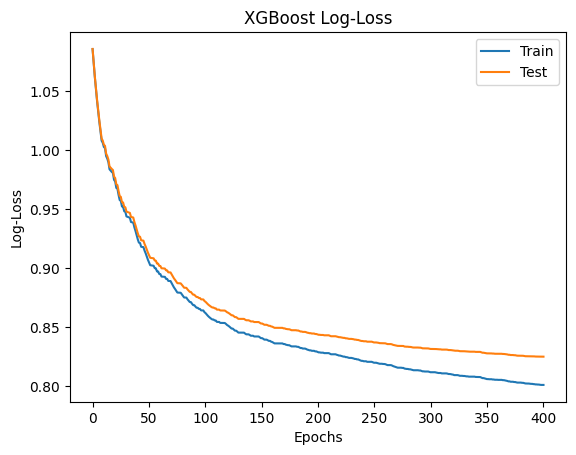

In [12]:
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Test')
plt.legend()
plt.ylabel('Log-Loss')
plt.xlabel('Epochs')
plt.title('XGBoost Log-Loss')
plt.show()

In [13]:
# plt.plot(x_axis, results['validation_0']['merror'], label='Train')
# plt.plot(x_axis, results['validation_1']['merror'], label='Test')
# plt.legend()
# plt.ylabel('Error')
# plt.xlabel('Epochs')
# plt.title('XGBoost Classification Error')
# plt.show()

Apply the model and then predict the BDT_scores for each of the classifications

In [14]:
# Predict class labels
y_pred = clf.predict(features_test)

# Predict class probabilities
y_proba = clf.predict_proba(features_test)

# BDT score for signal (numubarCC = class 2)
bdt_score_numubarcc = y_proba[:, 2]  # probability for class=2
bdt_score_numucc = y_proba[:, 1]  # probability for class=1
bdt_score_others = y_proba[:, 0]  # probability for class=0

# Optional: print a quick check of predicted classes
unique, counts = np.unique(y_pred, return_counts=True)
print("Predicted class distribution:", dict(zip(unique, counts)))

Predicted class distribution: {0: 15412, 1: 20555, 2: 10543}


Plot the Confusion matrix

Test Accuracy: 0.6121


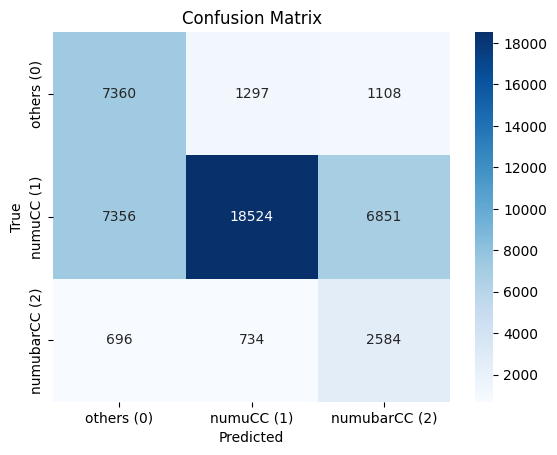

In [15]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(targets_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(targets_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['others (0)', 'numuCC (1)', 'numubarCC (2)'],
            yticklabels=['others (0)', 'numuCC (1)', 'numubarCC (2)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Extracting and Plotting ROC curve

In [16]:
# from sklearn import metrics
# def buildROC(target_test, test_preds, target_train, train_preds):
#     fpr_test, tpr_test, _ = metrics.roc_curve(target_test, test_preds)
#     fpr_train, tpr_train, _ = metrics.roc_curve(target_train, train_preds)
#     roc_auc_test = metrics.auc(fpr_test, tpr_test)
#     roc_auc_train = metrics.auc(fpr_train, tpr_train)
#     plt.title('Receiver Operating Characteristic')
#     plt.plot(fpr_test, tpr_test, label = 'Test - AUC = %0.2f' % roc_auc_test, color='g')
#     plt.plot(fpr_train, tpr_train, label = 'Train - AUC = %0.2f' % roc_auc_train, color='b')
#     plt.legend(loc = 'lower right')
#     plt.plot([0, 1], [0, 1],'r--')
#     plt.ylabel('True Positive Rate')
#     plt.xlabel('False Positive Rate')

In [17]:
y_pred_proba_train = clf.predict_proba(features_train)
y_pred_proba_test = clf.predict_proba(features_test)

In [18]:
# buildROC(targets_test, y_pred_proba_test[:, 1], targets_train, y_pred_proba_train[:, 1])

Feature Importance

In [19]:
# def plot_important_features(features, feature_importances_, number):
    
#     plt.close()
#     plt.figure(figsize=(8,5))
    
#     zipped = zip(features, feature_importances_)
#     zipped_sort = sorted(zipped, key = lambda x:x[1], reverse=True)
#     zipped_sort_reduced = zipped_sort[:number]
    
#     res = [[ i for i, j in zipped_sort_reduced], 
#            [ j for i, j in zipped_sort_reduced]]
#     red_features = res[0]
#     red_importances = res[1]
    
#     plt.barh(range(len(red_importances)), red_importances, align='center')
#     plt.yticks(np.arange(len(red_features)), red_features)
#     plt.xlabel("Feature importance")
#     plt.ylabel("Top %i features"%(number))
#     plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.1)
#     plt.tight_layout()
#     plt.show()
    
#     return red_features

In [20]:
def plot_important_features(features, feature_importances_, number):

    plt.close()
    plt.figure(figsize=(8,5))

    feature_name_map = {
        "Num_Muon": "Reconstructed Muon multiplicity",
        "Num_Gamma": "Reconstructed Photon multiplicity",
        "Num_Electron": "Reconstructed Electron multiplicity",
        "Num_Proton": "Reconstructed Proton multiplicity",
        "numu_1_score": r"$\nu_\mu$ CC tagger score",
        "numu_cc_3_track_length": "Total track length in main cluster",
        "numu_cc_3_max_length_all": "Max track length in main cluster",
        "numu_cc_3_max_length": "Max muon-candidate track length",
        "numu_cc_3_max_muon_length": "Max connected muon-track length",

        "cosmict_2_dQ_dx_front": r"Single-track candidate $dQ/dx$ at start",
        "cosmict_2_dQ_dx_end": r"Single-track candidate $dQ/dx$ at end",
        "cosmict_2_angle_beam": "Single-track candidate beam angle",
        "cosmict_2_phi": r"Single-track candidate $\phi$",

        "has_reco_michel": "Reconstructed Michel presence variable",
        "cos_theta": r"$\cos\theta$ (Reconstructed lepton-neutrino angle)",
    }

    zipped = zip(features, feature_importances_)
    zipped_sort = sorted(zipped, key=lambda x: x[1], reverse=True)
    zipped_sort_reduced = zipped_sort[:number]

    red_features = [i for i, j in zipped_sort_reduced]
    red_importances = [j for i, j in zipped_sort_reduced]

    red_features_display = [feature_name_map.get(f, f) for f in red_features]

    plt.barh(range(len(red_importances)), red_importances, align="center")
    plt.yticks(np.arange(len(red_features_display)), red_features_display)
    plt.gca().invert_yaxis()

    plt.xlabel("Feature importance", fontsize=14.5)
    plt.ylabel("Top %i features" % number, fontsize=14.5)

    plt.tight_layout()
    plt.show()

    return red_features

In [21]:
# from xgboost import plot_importance

# # Get the booster from your trained XGBClassifier
# booster = clf.get_booster()

# # Get the feature names (if you trained with DataFrame, else pass manually)
# feature_names = clf.get_booster().feature_names

# # Count how many trees per class
# n_classes = clf.n_classes_
# n_trees = len(booster.get_dump())  # total number of trees
# trees_per_class = n_trees // n_classes

# for class_id in range(n_classes):
#     # Plot only the trees corresponding to this class
#     ax = plot_importance(
#         booster,
#         importance_type='gain',   # or 'weight', 'cover', etc.
#         fmap='',  # no need unless using custom mapping
#         title=f"Feature Importance - Class {class_id}",
#         max_num_features=15,
#         height=0.5,
#         ax=None,
#         grid=False
#     )
#     ax.set_title(f"Feature Importance - Class {class_id}")
#     ax.set_xlim(right=ax.get_xlim()[1]*1.4)  # widen for visibility
#     ax.set_ylabel("Features")
#     plt.show()


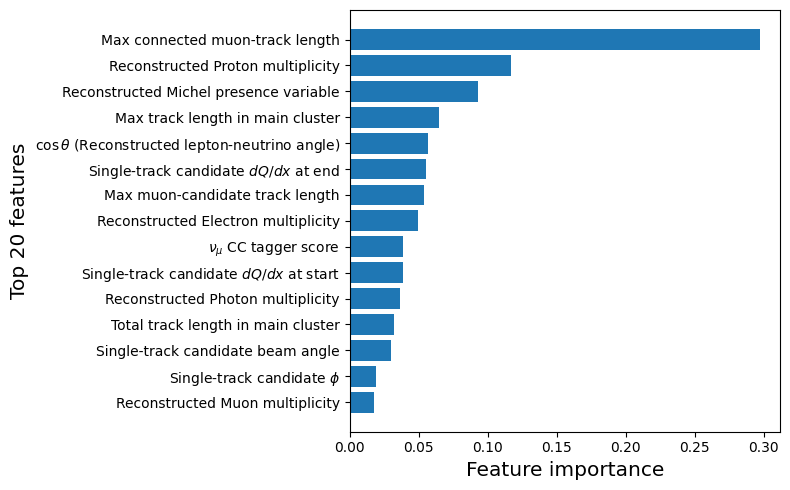

In [22]:
list_features = plot_important_features(training_variables, clf.feature_importances_, 20)

In [23]:
!pip install shap

/bin/bash: /home/s2106059/nu_mu_xsec/.venv/bin/pip: /scratch/wwang/nu_mu_xsec/.venv/bin/python: bad interpreter: No such file or directory


In [24]:
# Explain predictions using SHAP
explainer = shap.Explainer(clf)
shap_values = explainer(features_test)

feature_name_map = {
    "Num_Muon": "Reconstructed Muon multiplicity",
    "Num_Neutron": "Reconstructed Neutron multiplicity",
    "Num_Gamma": "Reconstructed Photon multiplicity",
    "Num_Electron": "Reconstructed Electron multiplicity",
    "Num_Proton": "Reconstructed Proton multiplicity",

    "numu_1_score": r"$\nu_\mu$ CC tagger score",
    "numu_cc_3_track_length": "Total track length in main cluster",
    "numu_cc_3_max_length_all": "Max track length in main cluster",
    "numu_cc_3_max_length": "Max muon-candidate track length",
    "numu_cc_3_max_muon_length": "Max connected muon-track length",

    "cosmict_2_dQ_dx_front": r"Single-track candidate $dQ/dx$ at start",
    "cosmict_2_dQ_dx_end": r"Single-track candidate $dQ/dx$ at end",
    "cosmict_2_angle_beam": "Single-track candidate beam angle",
    "cosmict_2_phi": r"Single-track candidate $\phi$",

    "has_reco_michel": "Reconstructed Michel presence variable",
    "cos_theta": r"$\cos\theta$ (Reconstructed lepton-neutrino angle)",
}

new_names = [feature_name_map.get(f, f) for f in features_test.columns]

shap_values_renamed = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=new_names
)


0 Axes(0.125,0.11;0.62x0.77)
1 Axes(0.78375,0.11;0.11625x0.77)


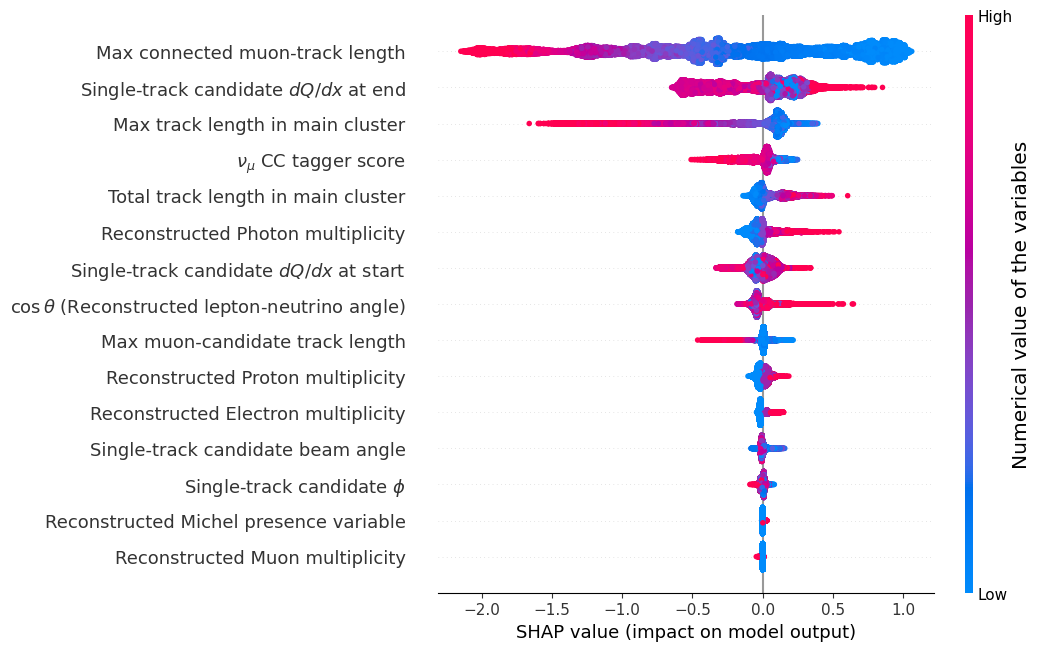

In [25]:
# Each prediction has shape [n_samples, n_classes, n_features]
# For summary plot, use per-class SHAP values
# To visualize class 0:
shap.plots.beeswarm(shap_values_renamed[..., 0], max_display=20, show=False)

fig = plt.gcf()

for i, ax in enumerate(fig.axes):
    print(i, ax)

if len(fig.axes) >= 2:
    fig.axes[1].set_ylabel("Numerical value of the variables", fontsize=14.5)

plt.show()

# To visualize class 1 or 2:
# shap.plots.beeswarm(shap_values_renamed[..., 1], max_display=20)
# shap.plots.beeswarm(shap_values_renamed[..., 2], max_display=20)

0 Axes(0.125,0.11;0.62x0.77)
1 Axes(0.78375,0.11;0.11625x0.77)


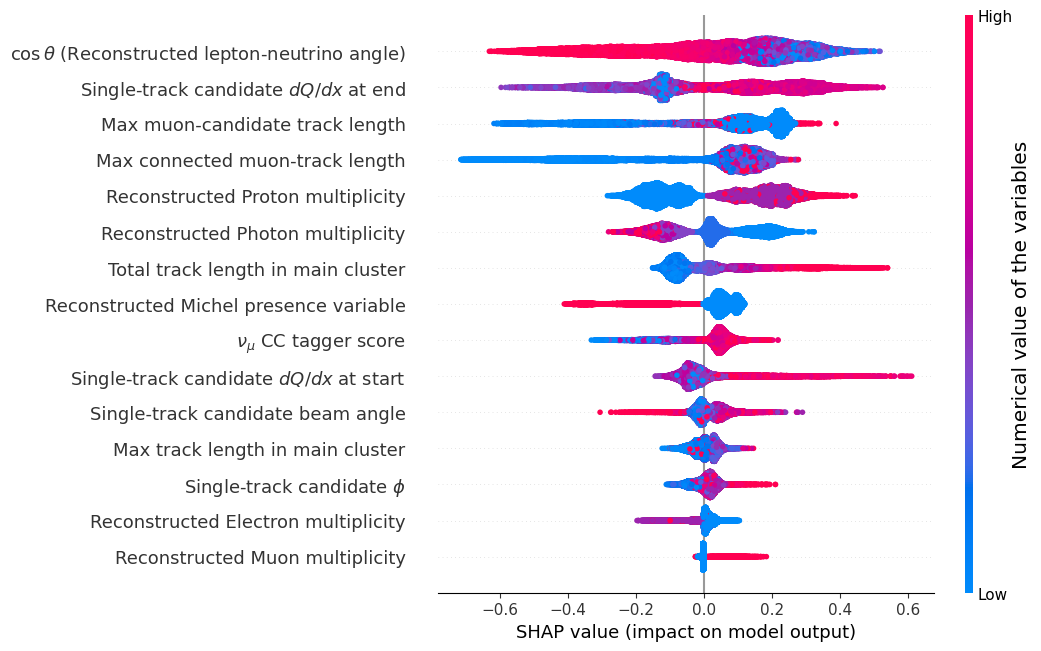

In [26]:
shap.plots.beeswarm(shap_values_renamed[..., 1], max_display=20, show=False)

fig = plt.gcf()

for i, ax in enumerate(fig.axes):
    print(i, ax)

if len(fig.axes) >= 2:
    fig.axes[1].set_ylabel("Numerical value of the variables", fontsize=14.5)

plt.show()

0 Axes(0.125,0.11;0.62x0.77)
1 Axes(0.78375,0.11;0.11625x0.77)


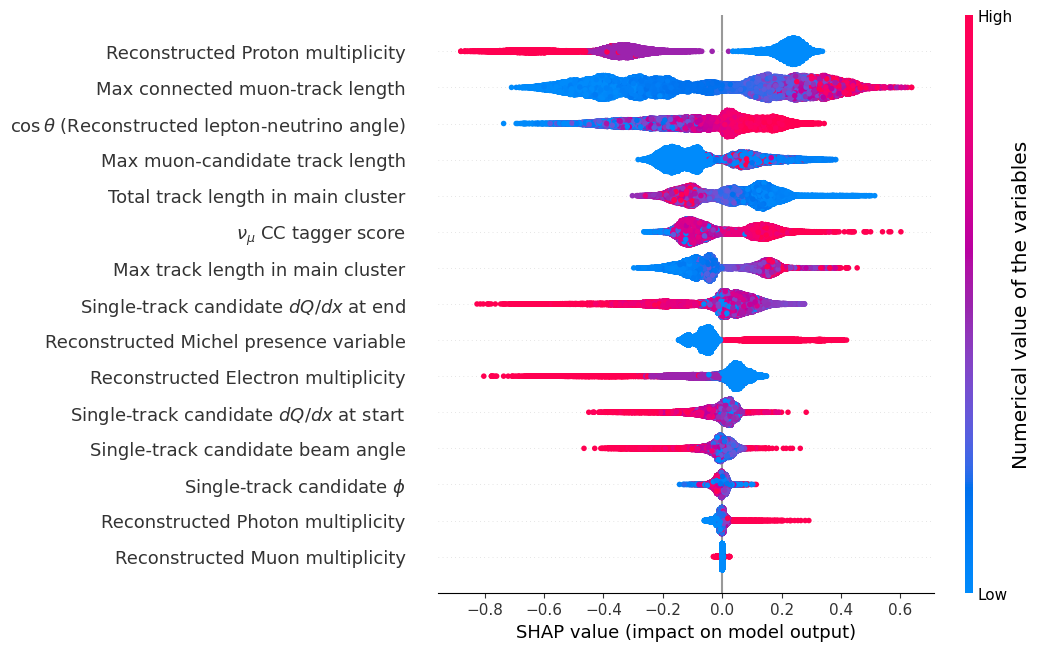

In [27]:
shap.plots.beeswarm(shap_values_renamed[..., 2], max_display=20, show=False)

# Change colorbar label
fig = plt.gcf()

for i, ax in enumerate(fig.axes):
    print(i, ax)

if len(fig.axes) >= 2:
    fig.axes[1].set_ylabel("Numerical value of the variables", fontsize=14.5)

plt.show()

Plot the BDT Score Distribution

[0.08459627 0.01269335 0.3622652  ... 0.48066154 0.01156452 0.6464831 ]
[0.85357904 0.09532149 0.32089213 ... 0.38137513 0.07544139 0.15131854]
[0.06182469 0.8919851  0.31684265 ... 0.13796328 0.9129941  0.20219831]


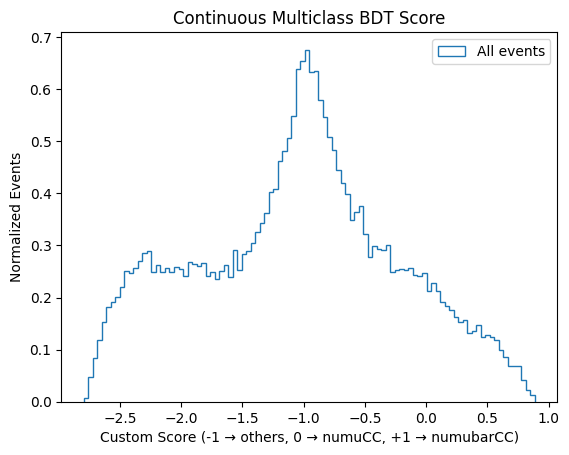

In [28]:
P0 = y_proba[:,0]  # others
P1 = y_proba[:,1]  # numuCC
P2 = y_proba[:,2]  # numubarCC

print(P0)
print(P1)
print(P2)

# Compute custom continuous score
score = -3*P0 - P1 + P2  # Custom score: -3 → others, -1 → numuCC, +1 → numubarCC; score = -3 * P0 - 1 * P1 + 1 * P2

# Plot the distribution of the custom score
plt.hist(score, bins=100, density=True, histtype='step', label='All events')
plt.xlabel('Custom Score (-1 → others, 0 → numuCC, +1 → numubarCC)')
plt.ylabel('Normalized Events')
plt.title('Continuous Multiclass BDT Score')
plt.legend()
plt.show()


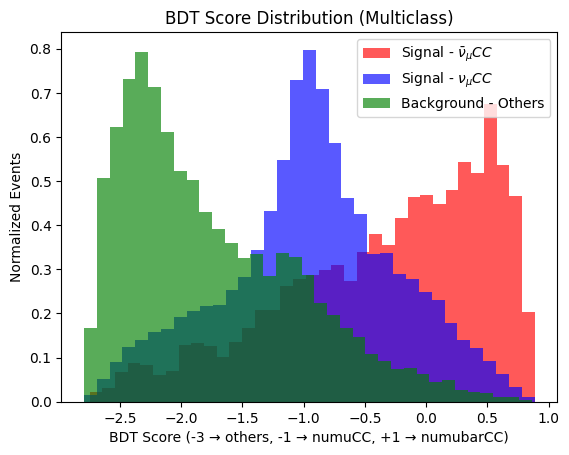

In [29]:
plt.hist(score[targets_test==2], bins=35, alpha=0.65, label=r'Signal - $\bar{\nu}_{\mu}CC$', color='red', density=True)
plt.hist(score[targets_test==1], bins=35, alpha=0.65, label=r'Signal - $\nu_{\mu}CC$', color='blue', density=True)
plt.hist(score[targets_test==0], bins=35, alpha=0.65, label='Background - Others', color='green', density=True)

plt.xlabel('BDT Score (-3 → others, -1 → numuCC, +1 → numubarCC)')
plt.ylabel('Normalized Events')
plt.title('BDT Score Distribution (Multiclass)')
plt.legend()
plt.show()

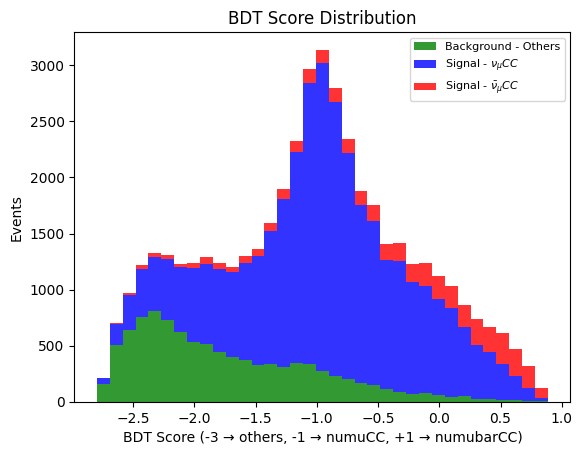

In [30]:
plt.hist(
    [score[targets_test == 0], score[targets_test == 1], score[targets_test == 2]],
    bins=35,
    stacked=True,
    color=['green', 'blue', 'red'],
    label=[
        'Background - Others',
        r'Signal - $\nu_{\mu}CC$',
        r'Signal - $\bar{\nu}_{\mu}CC$'
    ],
    density=False,
    alpha=0.8,
    log=False  # Enables log scale on the y-axis
)

plt.xlabel('BDT Score (-3 → others, -1 → numuCC, +1 → numubarCC)')
plt.ylabel('Events')
plt.title('BDT Score Distribution')
plt.legend(fontsize='8')
plt.show()


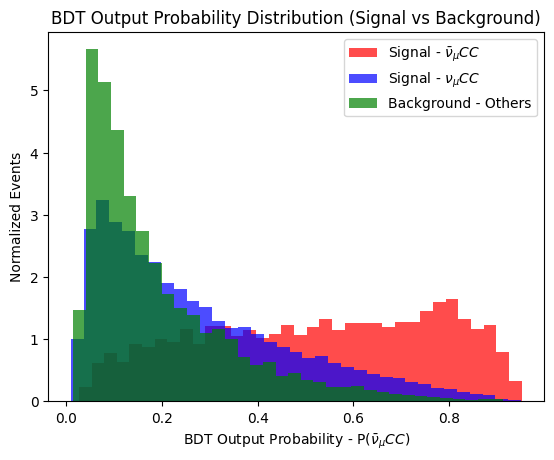

In [31]:
plt.hist(bdt_score_numubarcc[targets_test == 2], bins=35, alpha=0.7, label=r'Signal - $\bar{\nu}_{\mu}CC$', color='red', density=True)
plt.hist(bdt_score_numubarcc[targets_test == 1], bins=35, alpha=0.7, label=r'Signal - $\nu_{\mu}CC$', color='blue', density=True)
plt.hist(bdt_score_numubarcc[targets_test == 0], bins=35, alpha=0.7, label='Background - Others', color='green', density=True)
plt.xlabel(r'BDT Output Probability - P($\bar{\nu}_{\mu}CC$)')
plt.ylabel('Normalized Events')
plt.title('BDT Output Probability Distribution (Signal vs Background)')
plt.legend()
plt.show()

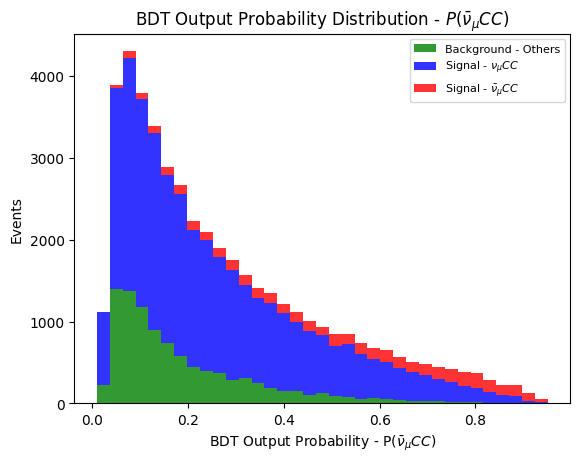

In [32]:
plt.hist(
    [
        bdt_score_numubarcc[targets_test == 0],
        bdt_score_numubarcc[targets_test == 1],
        bdt_score_numubarcc[targets_test == 2]
    ],
    bins=35,
    stacked=True,
    color=['green', 'blue', 'red'],
    label=[
        'Background - Others',
        r'Signal - $\nu_{\mu}CC$',
        r'Signal - $\bar{\nu}_{\mu}CC$'
    ],
    density=False,
    alpha=0.8,
    log=False
)

plt.xlabel(r'BDT Output Probability - P($\bar{\nu}_{\mu}CC$)')
plt.ylabel('Events')
plt.title(r'BDT Output Probability Distribution - $P(\bar{\nu}_{\mu}CC)$')
plt.legend(fontsize='8')
plt.show()

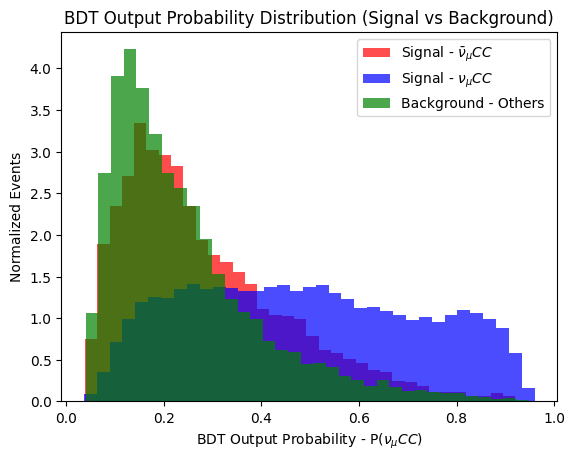

In [33]:
plt.hist(bdt_score_numucc[targets_test == 2], bins=35, alpha=0.7, label=r'Signal - $\bar{\nu}_{\mu}CC$', color='red', density=True)
plt.hist(bdt_score_numucc[targets_test == 1], bins=35, alpha=0.7, label=r'Signal - $\nu_{\mu}CC$', color='blue', density=True)
plt.hist(bdt_score_numucc[targets_test == 0], bins=35, alpha=0.7, label='Background - Others', color='green', density=True)
plt.xlabel(r'BDT Output Probability - P($\nu_{\mu}CC$)')
plt.ylabel('Normalized Events')
plt.title('BDT Output Probability Distribution (Signal vs Background)')
plt.legend()
plt.show()

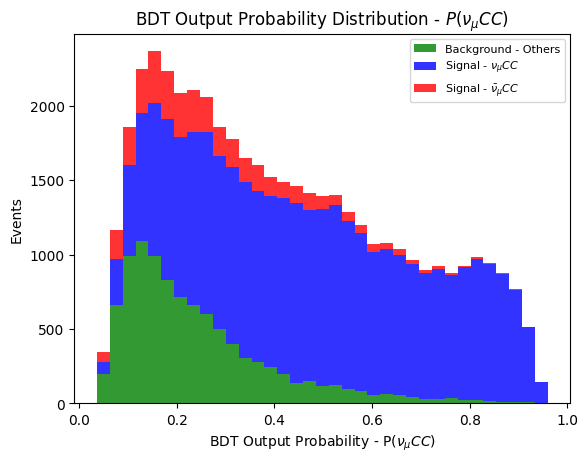

In [34]:
plt.hist(
    [
        bdt_score_numucc[targets_test == 0],
        bdt_score_numucc[targets_test == 1],
        bdt_score_numucc[targets_test == 2]
    ],
    bins=35,
    stacked=True,
    color=['green', 'blue', 'red'],
    label=[
        'Background - Others',
        r'Signal - $\nu_{\mu}CC$',
        r'Signal - $\bar{\nu}_{\mu}CC$'
    ],
    density=False,
    alpha=0.8,
    log=False
)

plt.xlabel(r'BDT Output Probability - P($\nu_{\mu}CC$)')
plt.ylabel('Events')
plt.title(r'BDT Output Probability Distribution - $P(\nu_{\mu}CC)$')
plt.legend(fontsize='8')
plt.show()

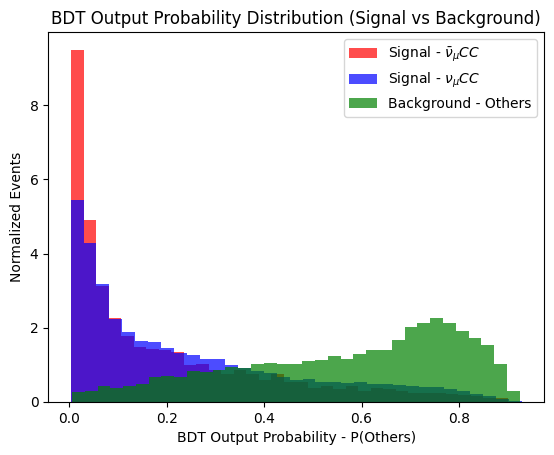

In [35]:
plt.hist(bdt_score_others[targets_test == 2], bins=35, alpha=0.7, label=r'Signal - $\bar{\nu}_{\mu}CC$', color='red', density=True)
plt.hist(bdt_score_others[targets_test == 1], bins=35, alpha=0.7, label=r'Signal - $\nu_{\mu}CC$', color='blue', density=True)
plt.hist(bdt_score_others[targets_test == 0], bins=35, alpha=0.7, label='Background - Others', color='green', density=True)
plt.xlabel(r'BDT Output Probability - P(Others)')
plt.ylabel('Normalized Events')
plt.title('BDT Output Probability Distribution (Signal vs Background)')
plt.legend()
plt.show()

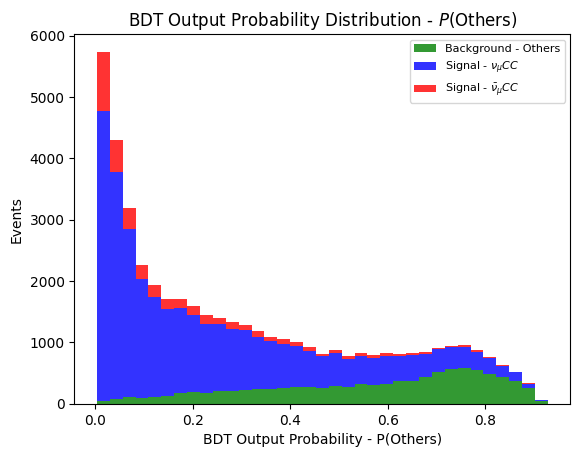

In [36]:
plt.hist(
    [
        bdt_score_others[targets_test == 0],
        bdt_score_others[targets_test == 1],
        bdt_score_others[targets_test == 2]
    ],
    bins=35,
    stacked=True,
    color=['green', 'blue', 'red'],
    label=[
        'Background - Others',
        r'Signal - $\nu_{\mu}CC$',
        r'Signal - $\bar{\nu}_{\mu}CC$'
    ],
    density=False,
    alpha=0.8,
    log=False
)

plt.xlabel(r'BDT Output Probability - P(Others)')
plt.ylabel('Events')
plt.title(r'BDT Output Probability Distribution - $P(\mathrm{Others})$')
plt.legend(fontsize='8')
plt.show()

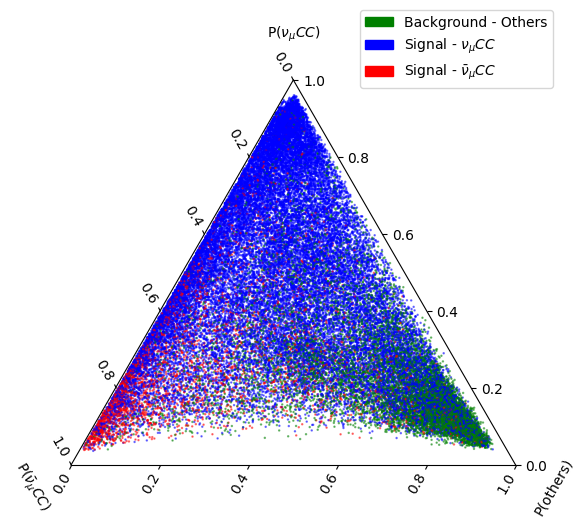

In [37]:
# Subsample the data (e.g., 30% of the data)
sample_size = int(1. * len(P1))  # Adjust 0.3 to the percentage you want
random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# Get the subsampled data
P1_subsample = np.array(P1)[random_indices]
P2_subsample = np.array(P2)[random_indices]
P0_subsample = np.array(P0)[random_indices]
targets_test_subsample = np.array(targets_test)[random_indices]

# Color mapping by class
color_map = {0: 'green', 1: 'blue', 2: 'red'}
label_map = {0: 'Background - Others', 1: r'Signal - $\nu_{\mu}CC$', 2: r'Signal - $\bar{\nu}_{\mu}CC$'}
colors = [color_map[label] for label in targets_test_subsample]

# Plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='ternary')
sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample, c=colors, alpha=0.5, s=0.6)

# Labels on triangle sides
ax.set_tlabel(r'P($\nu_{\mu}CC$)')
ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
ax.set_rlabel('P(others)')

# Legend
handles = [mpatches.Patch(color=clr, label=label_map[key]) for key, clr in color_map.items()]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.1, 1.2))

plt.show()


In [38]:
# # Suppose cos_theta is your array of cos(theta) values (same length as P1, P2, P0)
# # For example:
# # cos_theta = np.array([...])  # your data here

# # Subsample if needed (optional, but as before)
# sample_size = int(1.0 * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# cos_theta_subsample = np.array(features_test["cos_theta"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=cos_theta_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.4, s=1.2)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label(r'$\cos(\theta)$')

# plt.tight_layout()
# plt.show()


In [39]:
# # Suppose cos_theta is your array of cos(theta) values (same length as P1, P2, P0)
# # For example:
# # cos_theta = np.array([...])  # your data here

# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# num_proton_subsample = np.array(features_test["Num_Proton"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=num_proton_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.6, s=0.9)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label("Proton Multiplicity")

# plt.tight_layout()
# plt.show()


In [40]:
# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# mu_energy_subsample = np.array(features_test["truth_cos_theta"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=mu_energy_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.4, s=1.2)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label(r"Reconstructed Michel-Muon cos(\theta)")

# plt.tight_layout()
# plt.show()

In [41]:
# # Suppose cos_theta is your array of cos(theta) values (same length as P1, P2, P0)
# # For example:
# # cos_theta = np.array([...])  # your data here

# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# num_proton_subsample = np.array(features_test["Truth_Num_Proton"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=num_proton_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.6, s=0.9)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label("Proton Multiplicity")

# plt.tight_layout()
# plt.show()


## Truth version

In [42]:
# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# mu_energy_subsample = np.array(features_test["has_truth_michel"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=mu_energy_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.4, s=1.2)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label("Truth Michel Presence (A.U.)")

# plt.tight_layout()
# plt.show()

In [43]:
# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# mu_energy_subsample = np.array(features_test["truth_michel_energy"]*1000)[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=mu_energy_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.4, s=1.2)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label("Truth Michel Energy (MeV)")

# plt.tight_layout()
# plt.show()

In [44]:
# # Subsample if needed (optional, but as before)
# sample_size = int(1. * len(P1))
# random_indices = np.random.choice(len(P1), size=sample_size, replace=False)

# P1_subsample = np.array(P1)[random_indices]
# P2_subsample = np.array(P2)[random_indices]
# P0_subsample = np.array(P0)[random_indices]
# mu_energy_subsample = np.array(features_test["truth_michel_muon_costheta"])[random_indices]

# # Plot
# fig = plt.figure(figsize=(7, 6))
# ax = fig.add_subplot(1, 1, 1, projection='ternary')

# # Scatter with continuous coloring based on cos(theta)
# sc = ax.scatter(P1_subsample, P2_subsample, P0_subsample,
#                 c=mu_energy_subsample, cmap='viridis',  # you can change cmap here
#                 alpha=0.4, s=1.2)

# # Labels on triangle sides
# ax.set_tlabel(r'P($\nu_{\mu}CC$)')
# ax.set_llabel(r'P($\bar{\nu}_{\mu}CC$)')
# ax.set_rlabel('P(others)')

# # Add color bar
# cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label(r"Truth Michel-Muon cos($\theta$)")

# plt.tight_layout()
# plt.show()

# Plotting ROC Curves (each class vs rest)

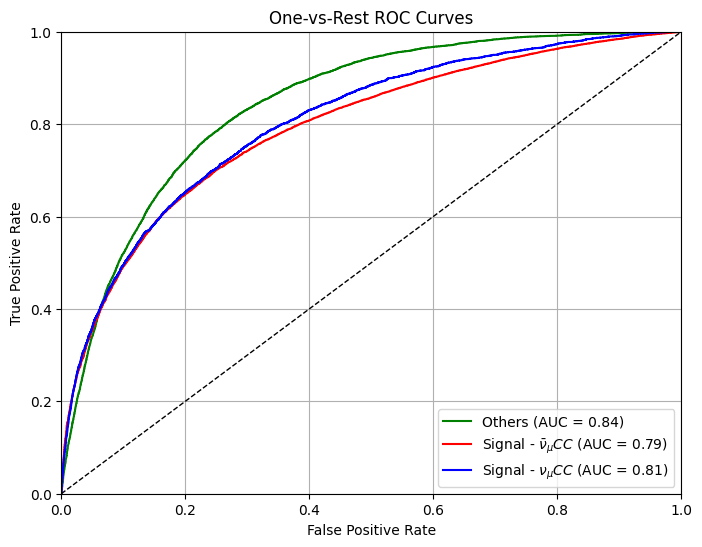

In [45]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume targets_test and y_proba from your test set
# targets_test ∈ {0,1,2}
# y_proba.shape = (n_samples, 3)

# Binarize the true labels for multiclass ROC
targets_test_bin = label_binarize(targets_test, classes=[0,1,2])  # shape (n_samples, 3)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(targets_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))
colors = ['green', 'red', 'blue']
labels = ['Others', r'Signal - $\bar{\nu}_{\mu}CC$', r'Signal - $\nu_{\mu}CC$']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.grid()
plt.show()


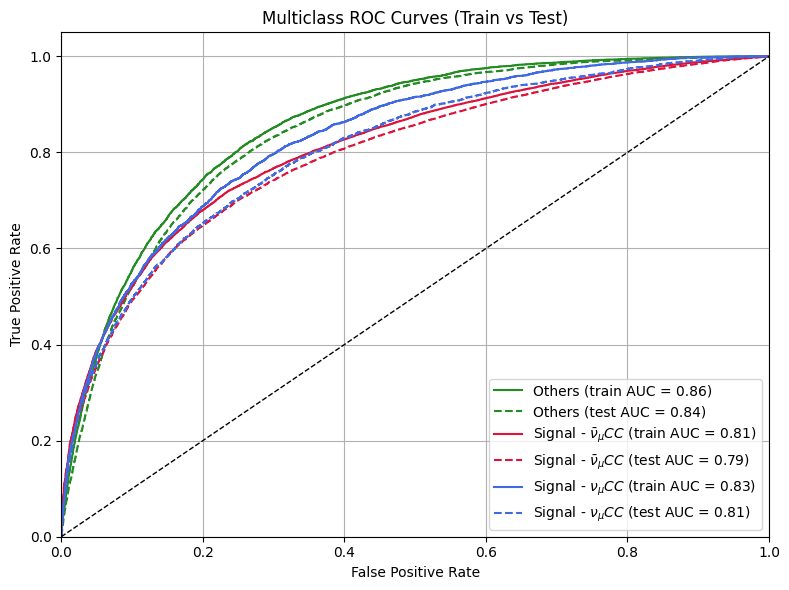

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ---- Predict probabilities ----
y_proba_train = clf.predict_proba(features_train)  # shape (n_train, 3)
y_proba_test = clf.predict_proba(features_test)    # shape (n_test, 3)

# ---- Binarize targets ----
classes = [0, 1, 2]  # others, numuCC, numubarCC
targets_train_bin = label_binarize(targets_train, classes=classes)
targets_test_bin  = label_binarize(targets_test, classes=classes)

# ---- Compute ROC + AUC for train/test, per class ----
fpr_train, tpr_train, auc_train = {}, {}, {}
fpr_test, tpr_test, auc_test = {}, {}, {}
n_classes = len(classes)

for i in range(n_classes):
    fpr_train[i], tpr_train[i], _ = roc_curve(targets_train_bin[:, i], y_proba_train[:, i])
    auc_train[i] = auc(fpr_train[i], tpr_train[i])
    
    fpr_test[i], tpr_test[i], _ = roc_curve(targets_test_bin[:, i], y_proba_test[:, i])
    auc_test[i] = auc(fpr_test[i], tpr_test[i])

# ---- Plot ----
plt.figure(figsize=(8,6))
colors = ['forestgreen', 'crimson', 'royalblue']
labels = ['Others', r'Signal - $\bar{\nu}_{\mu}CC$', r'Signal - $\nu_{\mu}CC$']

for i in range(n_classes):
    plt.plot(fpr_train[i], tpr_train[i], color=colors[i], linestyle='-', 
             label=f'{labels[i]} (train AUC = {auc_train[i]:.2f})')
    plt.plot(fpr_test[i], tpr_test[i], color=colors[i], linestyle='--', 
             label=f'{labels[i]} (test AUC = {auc_test[i]:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (Train vs Test)')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()


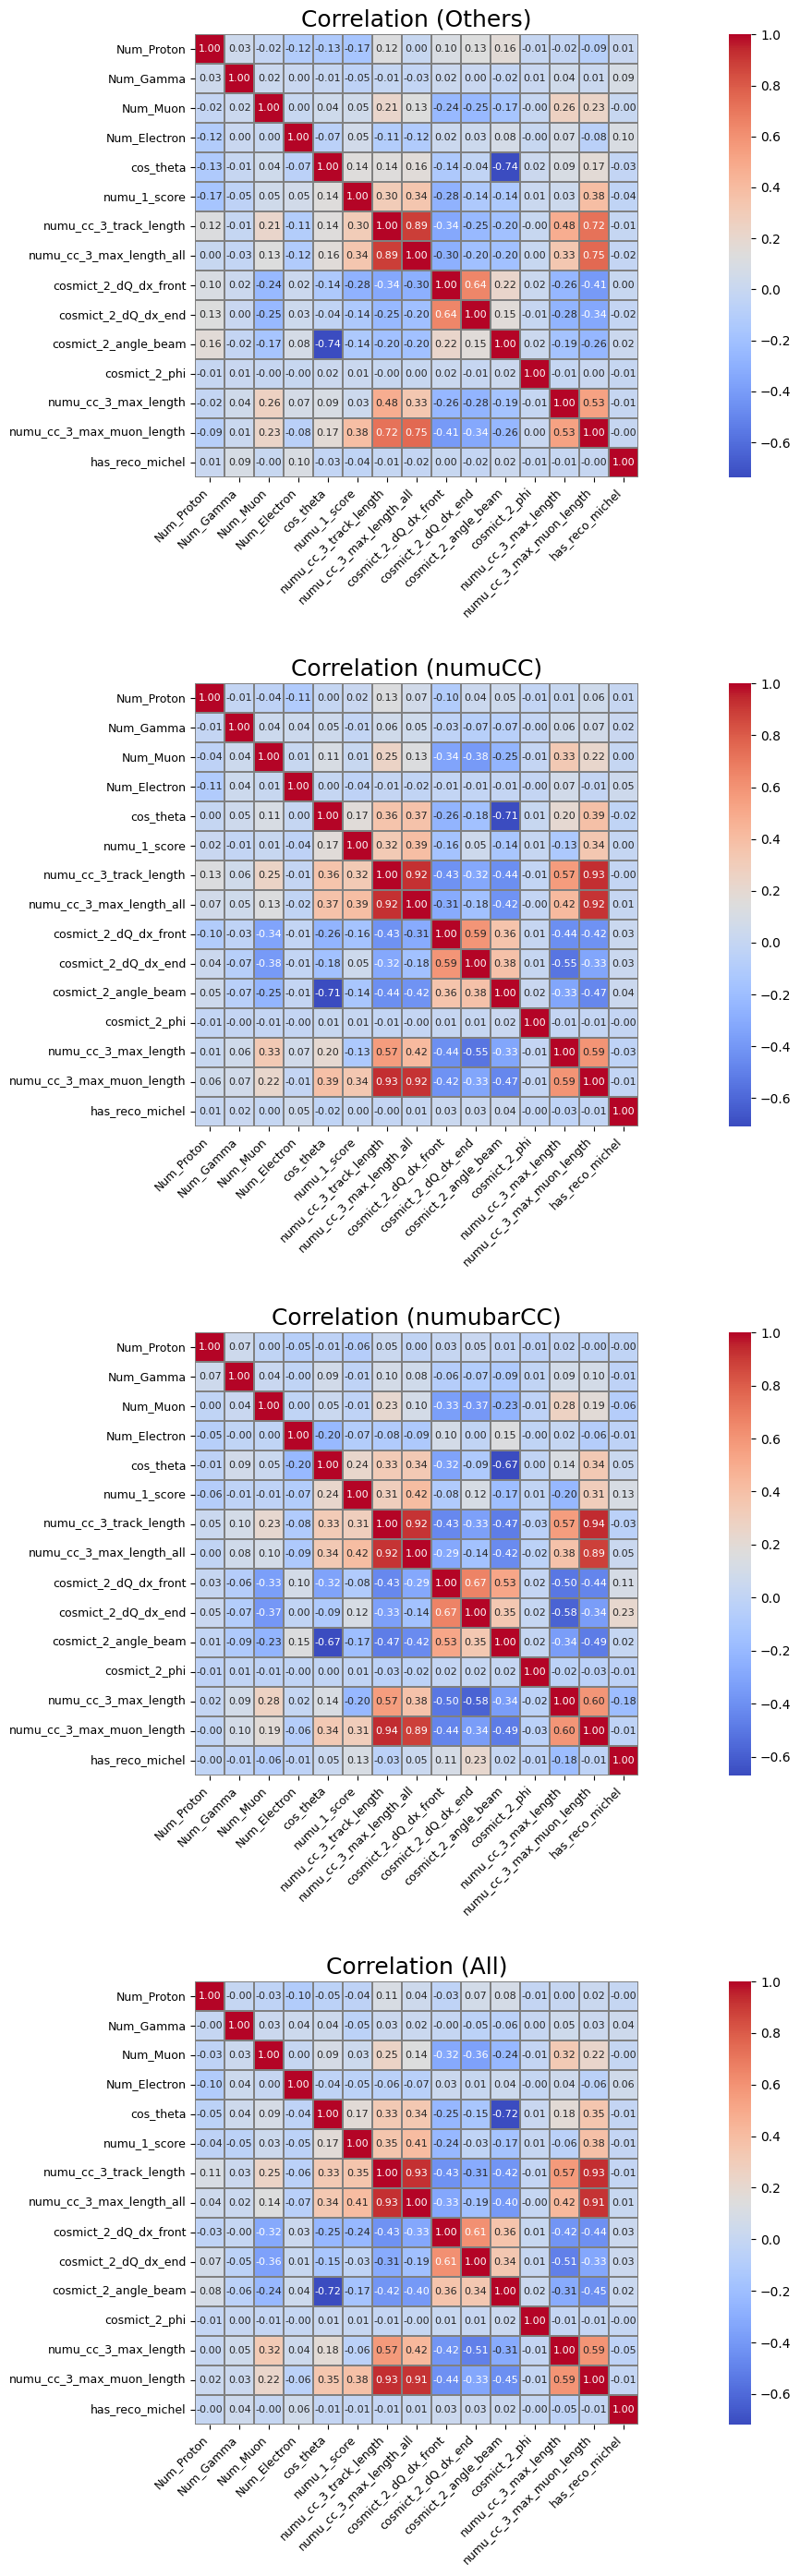

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Split the dataframe by class label
df_others = df_bdt[df_bdt["bdt_multi_label"] == 0]
df_numu   = df_bdt[df_bdt["bdt_multi_label"] == 1]
df_numubar = df_bdt[df_bdt["bdt_multi_label"] == 2]

# Compute correlation matrices
corr_others = df_others[training_variables].corr()
corr_numu = df_numu[training_variables].corr()
corr_numubar = df_numubar[training_variables].corr()
corr_all = df_bdt[training_variables].corr()

fig, axes = plt.subplots(4, 1, figsize=(20, 28))  # Wider and taller
titles = ["Correlation (Others)", "Correlation (numuCC)", "Correlation (numubarCC)", "Correlation (All)"]
corr_matrices = [corr_others, corr_numu, corr_numubar, corr_all]

for ax, corr, title in zip(axes, corr_matrices, titles):
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",  # Fewer decimal places
        cmap="coolwarm",
        ax=ax,
        cbar=True,
        square=True,
        annot_kws={"size": 8},  # Smaller font for numbers
        linewidths=0.3,
        linecolor='gray'
    )
    ax.set_title(title, fontsize=18)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout(h_pad=3.0)  # Add vertical padding between plots
plt.show()


In [48]:
# # First Calulate BDT score
# #df_bdt.loc[:,bdt_score] = clf.predict_proba(df_bdt[training_variables])[:,1]
# df_bdt['bdt_score'] = clf.predict_proba(df_bdt[training_variables])[:,1]

# y_pred_proba_sig_train = clf.predict_proba(features_test_sig)
# y_pred_proba_bkg_train = clf.predict_proba(features_test_bkg)
# bdtScoreSigTrain = y_pred_proba_sig_train[:,-1]
# bdtScoreBkgTrain = y_pred_proba_bkg_train[:,-1]

In [49]:
# plt.hist(bdtScoreSigTrain, 25, color='orange', range=(0.,1.), label=r'Signal - $\bar{\nu}_{\mu}CC$', alpha=0.5, density=False)
# plt.hist(bdtScoreBkgTrain, 25, color='green', range=(0.,1.), label= r'Background - $\nu_{\mu}CC$ and Others', alpha=0.5, density=False)

# plt.xlabel("BDT Prediction Score")
# plt.ylabel("Entries")
# plt.legend(fontsize=8, loc='best', frameon=False)
# plt.show()

In [50]:
# cut = 0.76
# signal_cut = bdtScoreSigTrain[bdtScoreSigTrain>=cut]
# bkg_cut = bdtScoreBkgTrain[bdtScoreBkgTrain>=cut]

# signal_cut_accuracy = signal_cut.size/(signal_cut.size+bkg_cut.size)
# bkg_cut_accuracy = bkg_cut.size/(signal_cut.size+bkg_cut.size)
# print("the sig accuracy %.3f and bkg accuracy is %.3f" % (signal_cut_accuracy, bkg_cut_accuracy))
# print(signal_cut.size)
# print(bkg_cut.size)
# print(bdtScoreSigTrain.size)

In [51]:
# plot signal and background separately
# plt.figure();
# plt.hist(predictions[test.get_label().astype(bool)],bins=np.linspace(0,1,50),
#          histtype='step',color='midnightblue',label='signal');
# plt.hist(predictions[~(test.get_label().astype(bool))],bins=np.linspace(0,1,50),
#          histtype='step',color='firebrick',label='background');
# # make the plot readable
# plt.xlabel('Prediction from BDT',fontsize=12);
# plt.ylabel('Events',fontsize=12);
# plt.legend(frameon=False);

Plot the confusion matrix

In [52]:
# mc_y_pred = clf.predict(features_test)

# group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
# cm_mc = confusion_matrix(targets_test, mc_y_pred)
# test_counts = ["{0:0.0f}".format(value) for value in cm_mc.flatten()]
# test_percentage = ["{0:.2%}".format(value) for value in cm_mc.flatten()/np.sum(cm_mc)]
# test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
# test_labels = np.asarray(test_labels).reshape(2,2)
# ax= plt.subplot()
# sns.heatmap(cm_mc, annot=test_labels, fmt='', cmap='Blues', ax=ax);
# tn, fp, fn, tp = cm_mc.ravel()
# print(tn, fp, fn, tp)
# # labels, title and ticks

# ax.set_title('BDT Model Confusion Matrix'); 
# ax.set_xlabel("Predicted Label")
# ax.set_ylabel("True Label")
# ax.xaxis.set_ticklabels(['Negative', 'Positive']); 
# ax.yaxis.set_ticklabels(['Negative', 'Positive']);

## Plotting Particle Multiplicity

In [53]:
# First set a mask for plotting multiplicity
df_numucc = df_bdt.query('bdt_multi_label==1')
df_numubar = df_bdt.query('bdt_multi_label==2')
df_others = df_bdt.query('bdt_multi_label==0')

In [54]:
df_bdt.head()

,kine_reco_Enu,kine_pio_mass,kine_pio_flag,kine_pio_vtx_dis,kine_pio_energy_1,kine_pio_energy_2,kine_pio_dis_1,kine_pio_dis_2,kine_pio_angle,numu_cc_flag,...,norm_vec_targ_vtx_truth,norm_vec_shower_truth,truth_cos_theta,RSE,has_reco_michel,has_truth_michel,bdt_numubarcc_label,bdt_numucc_label,bdt_others_label,bdt_multi_label
5736,612.621277,0.000000,0,1000.0,0.000000,0.000000,0.0,0.000000,0.000000,1.0,...,68501.831924,0.526373,0.647805,7319_3_159,0,0,0,1,0,1
5759,603.278931,0.000000,0,1000.0,0.000000,0.000000,0.0,0.000000,0.000000,1.0,...,68337.853623,0.563154,0.796854,7713_20_1026,1,0,0,1,0,1
5760,166.872513,0.000000,0,1000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,68449.716617,1.016590,0.734098,7713_21_1055,0,0,0,0,1,0
5767,437.438629,0.000000,0,1000.0,0.000000,0.000000,0.0,0.000000,0.000000,1.0,...,68315.049085,4.232513,0.978544,7713_27_1357,0,0,0,0,1,0
5772,679.708374,15.338706,1,0.0,24.242733,4.304889,0.0,59.621387,102.380211,1.0,...,68111.877268,0.245196,0.222363,7713_30_1544,0,0,0,0,1,0


In [55]:
def plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                               column, xlabel, max_val=None, width=0.2):
    """
    Plot side-by-side bar distributions for a discrete multiplicity variable.

    Parameters
    ----------
    df_numucc : pd.DataFrame
        DataFrame for νμCC events
    df_numubar : pd.DataFrame
        DataFrame for ν̄μCC events
    df_others : pd.DataFrame
        DataFrame for other events
    column : str
        Column name to plot (e.g., 'Truth_Num_Proton', 'Num_Gamma')
    xlabel : str
        X-axis label
    max_val : int or None
        Maximum multiplicity to plot (bins go from 0..max_val).
        If None, inferred from the three DataFrames.
    width : float
        Width of each bar (controls spacing between groups).
    """

    # Auto-determine range if not provided
    if max_val is None:
        max_val = int(max(
            df_numucc[column].max(),
            df_numubar[column].max(),
            df_others[column].max()
        )) + 1

    bins = np.arange(0, max_val + 1)

    # Histogram counts
    counts_numu, _    = np.histogram(df_numucc[column], bins=bins)
    counts_numubar, _ = np.histogram(df_numubar[column], bins=bins)
    counts_others, _  = np.histogram(df_others[column], bins=bins)

    # Normalize each to area = 1
    counts_numu    = counts_numu / counts_numu.sum() if counts_numu.sum() > 0 else counts_numu
    counts_numubar = counts_numubar / counts_numubar.sum() if counts_numubar.sum() > 0 else counts_numubar
    counts_others  = counts_others / counts_others.sum() if counts_others.sum() > 0 else counts_others

    x = bins[:-1]  # integer values

    plt.bar(x - width, counts_numu, width=width,
            label=r'$\nu_{\mu}CC$', color='blue', alpha=0.6, hatch='\\\\')
    plt.bar(x, counts_numubar, width=width,
            label=r'$\bar{\nu}_{\mu}CC$', color='maroon', alpha=0.6, hatch='////')
    plt.bar(x + width, counts_others, width=width,
            label='Others', color='paleturquoise', alpha=0.6, hatch='//')

    plt.xticks(x, x)
    plt.xlabel(xlabel)
    plt.ylabel("Area Normalized")
    plt.legend()
    plt.tight_layout()
    plt.show()


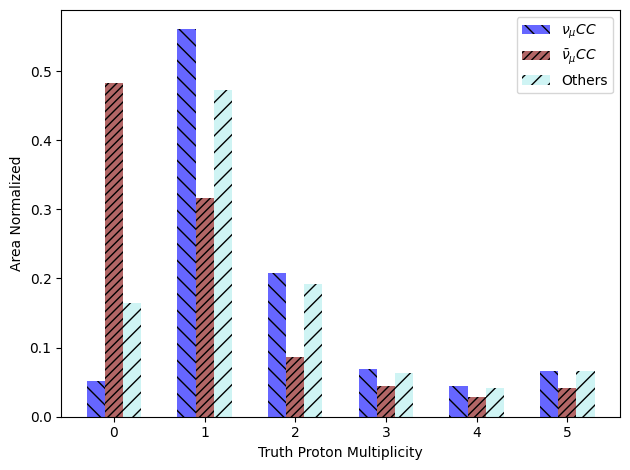

In [56]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Proton",
                           xlabel="Truth Proton Multiplicity",
                           max_val=6)

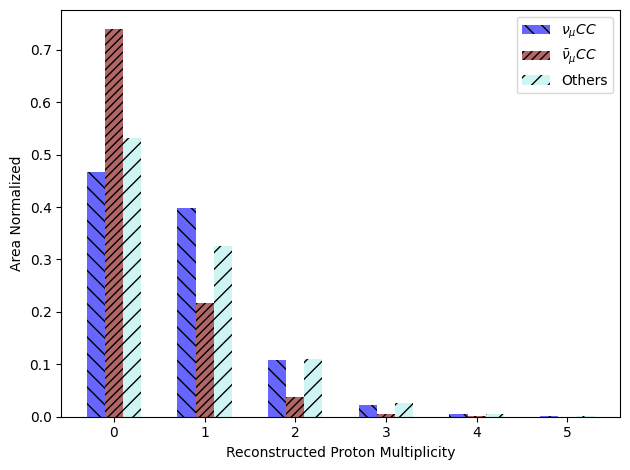

In [57]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Proton",
                           xlabel="Reconstructed Proton Multiplicity",
                           max_val=6)

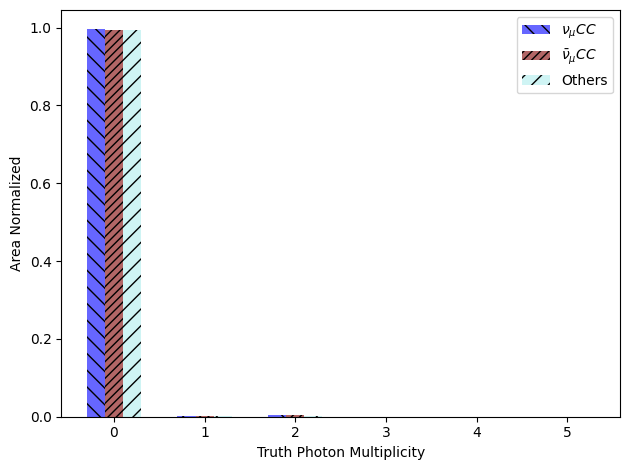

In [58]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Gamma",
                           xlabel="Truth Photon Multiplicity",
                           max_val=6)

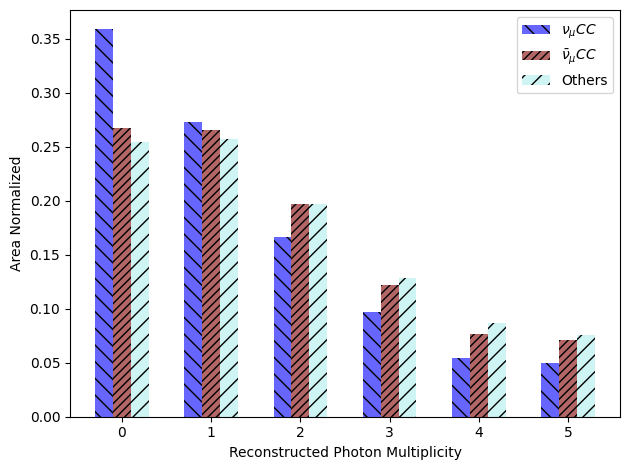

In [59]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Gamma",
                           xlabel="Reconstructed Photon Multiplicity",
                           max_val=6)

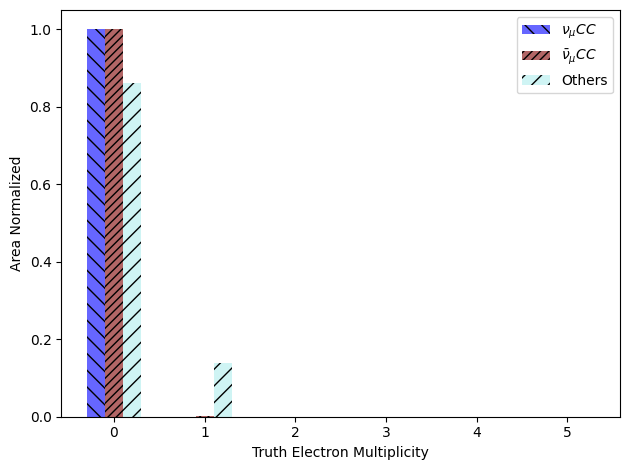

In [60]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Electron",
                           xlabel="Truth Electron Multiplicity",
                           max_val=6)

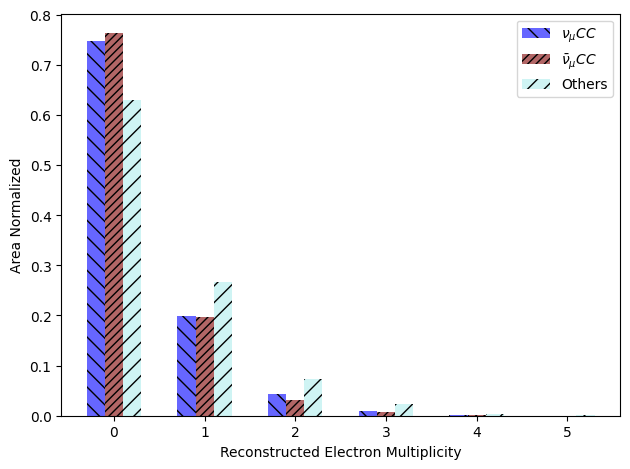

In [61]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Electron",
                           xlabel="Reconstructed Electron Multiplicity",
                           max_val=6)

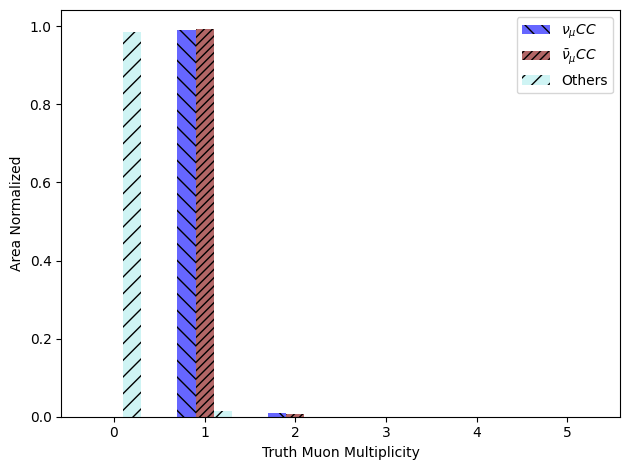

In [62]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Muon",
                           xlabel="Truth Muon Multiplicity",
                           max_val=6)

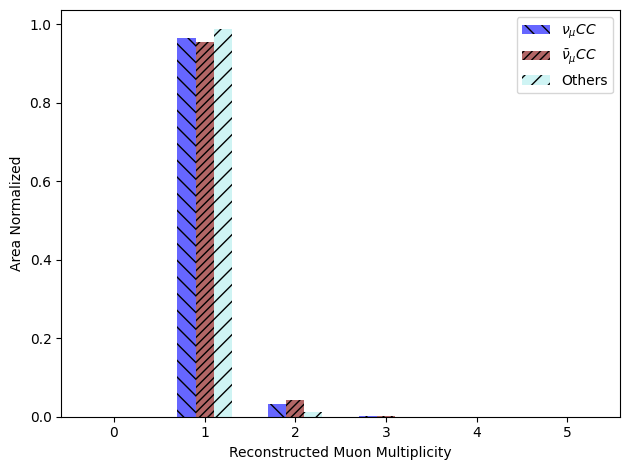

In [63]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Muon",
                           xlabel="Reconstructed Muon Multiplicity",
                           max_val=6)

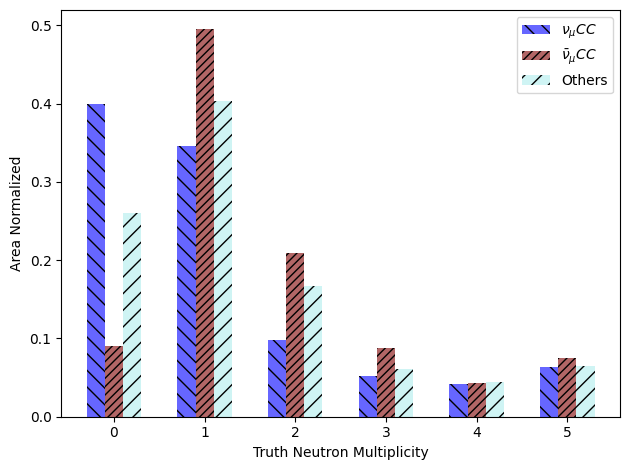

In [64]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Neutron",
                           xlabel="Truth Neutron Multiplicity",
                           max_val=6)

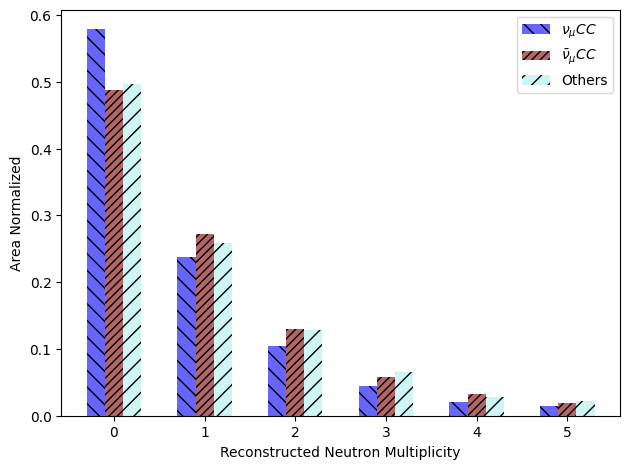

In [65]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Neutron",
                           xlabel="Reconstructed Neutron Multiplicity",
                           max_val=6)

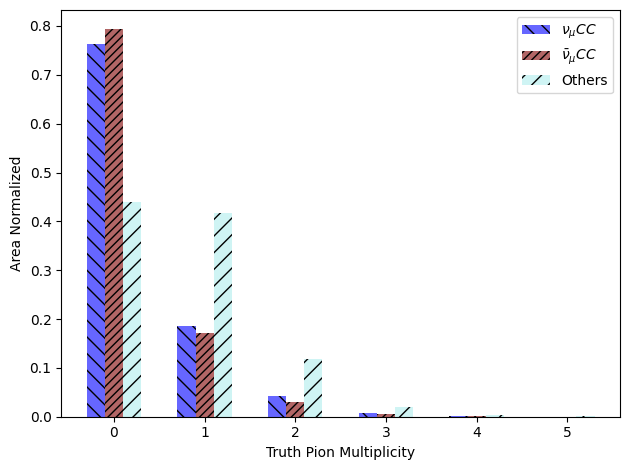

In [66]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Truth_Num_Pion",
                           xlabel="Truth Pion Multiplicity",
                           max_val=6)

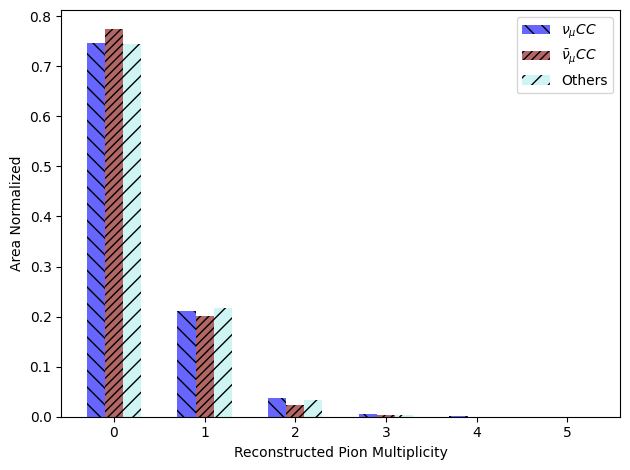

In [67]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="Num_Pion",
                           xlabel="Reconstructed Pion Multiplicity",
                           max_val=6)

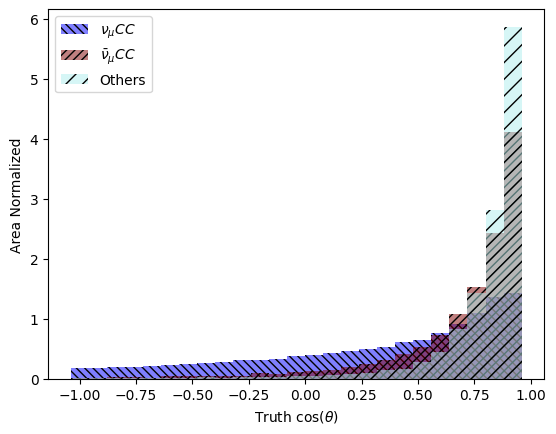

In [68]:
plt.hist(df_numucc['truth_cos_theta'], 25, (-1,1), density=True, label=r'$\nu_{\mu}CC$', align='left', alpha=.5, color='blue',hatch='\\\\\\\\')
plt.hist(df_numubar['truth_cos_theta'], 25, (-1,1), density=True, label= r'$\bar{\nu}_{\mu}CC$', align='left', alpha=.5, color='maroon',hatch='////')
plt.hist(df_others['truth_cos_theta'], 25, (-1,1), density=True, label= r'Others', align='left', alpha=.5, color='paleturquoise',hatch='//')
plt.xlabel(r"Truth cos($\theta$)")
plt.ylabel("Area Normalized")
plt.legend()
plt.show()

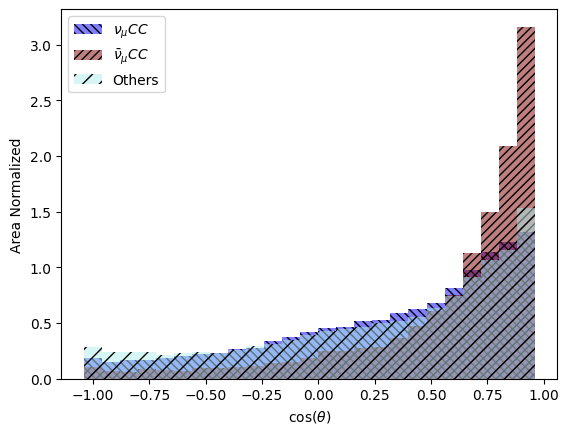

In [69]:
plt.hist(df_numucc['cos_theta'], 25, (-1,1), density=True, label=r'$\nu_{\mu}CC$', align='left', alpha=.5, color='blue',hatch='\\\\\\\\')
plt.hist(df_numubar['cos_theta'], 25, (-1,1), density=True, label= r'$\bar{\nu}_{\mu}CC$', align='left', alpha=.5, color='maroon',hatch='////')
plt.hist(df_others['cos_theta'], 25, (-1,1), density=True, label= r'Others', align='left', alpha=.5, color='paleturquoise',hatch='//')
plt.xlabel(r"cos($\theta$)")
plt.ylabel("Area Normalized")
plt.legend()
plt.show()

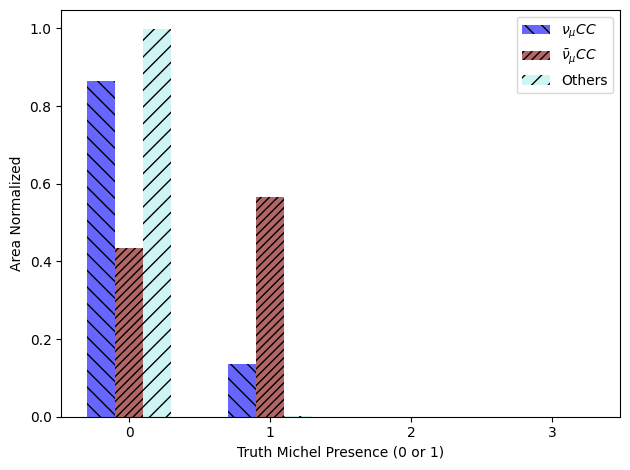

In [70]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="has_truth_michel",
                           xlabel="Truth Michel Presence (0 or 1)",
                           max_val=4)

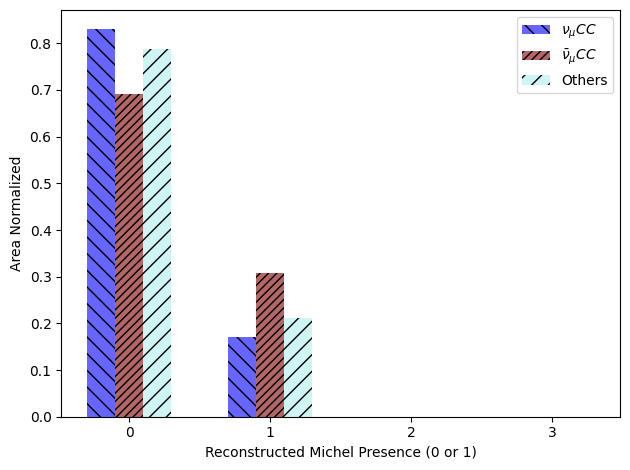

In [71]:
plot_discrete_multiplicity(df_numucc, df_numubar, df_others,
                           column="has_reco_michel",
                           xlabel="Reconstructed Michel Presence (0 or 1)",
                           max_val=4)

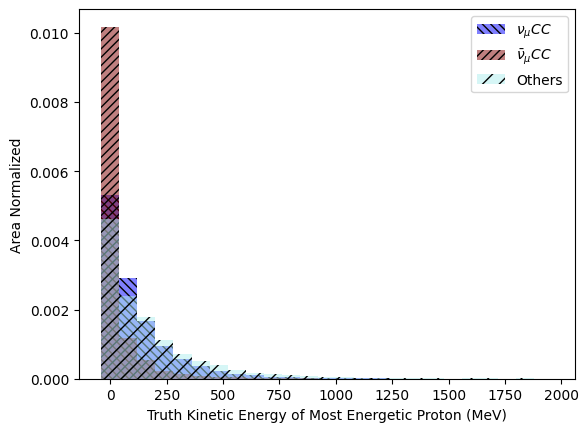

In [72]:
plt.hist(df_numucc['Truth_Proton_Tmax'], 25, (0.,2000.), density=True, label=r'$\nu_{\mu}CC$', align='left', alpha=.5, color='blue',hatch='\\\\\\\\')
plt.hist(df_numubar['Truth_Proton_Tmax'], 25, (0.,2000.), density=True, label= r'$\bar{\nu}_{\mu}CC$', align='left', alpha=.5, color='maroon',hatch='////')
plt.hist(df_others['Truth_Proton_Tmax'], 25, (0.,2000.), density=True, label= r'Others', align='left', alpha=.5, color='paleturquoise',hatch='//')
plt.xlabel("Truth Kinetic Energy of Most Energetic Proton (MeV)")
plt.ylabel("Area Normalized")
plt.legend()
plt.show()

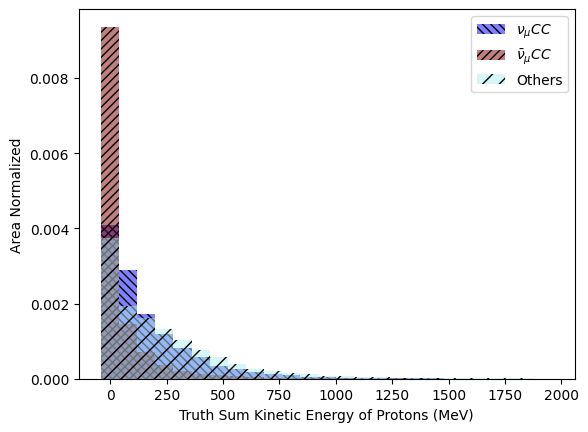

In [73]:
plt.hist(df_numucc['Truth_Proton_Tsum'], 25, (0.,2000.), density=True, label=r'$\nu_{\mu}CC$', align='left', alpha=.5, color='blue',hatch='\\\\\\\\')
plt.hist(df_numubar['Truth_Proton_Tsum'], 25, (0.,2000.), density=True, label= r'$\bar{\nu}_{\mu}CC$', align='left', alpha=.5, color='maroon',hatch='////')
plt.hist(df_others['Truth_Proton_Tsum'], 25, (0.,2000.), density=True, label= r'Others', align='left', alpha=.5, color='paleturquoise',hatch='//')
plt.xlabel("Truth Sum Kinetic Energy of Protons (MeV)")
plt.ylabel("Area Normalized")
plt.legend()
plt.show()

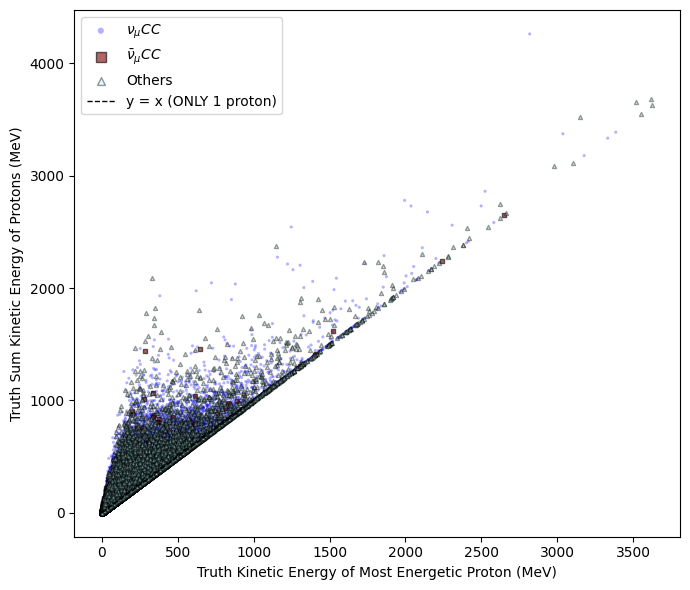

In [74]:
plt.figure(figsize=(7,6))

plt.scatter(df_numucc['Truth_Proton_Tmax'], df_numucc['Truth_Proton_Tsum'],
            label=r'$\nu_{\mu}CC$', alpha=0.3, color='blue', marker='o', s=5, edgecolors='none')

plt.scatter(df_numubar['Truth_Proton_Tmax'], df_numubar['Truth_Proton_Tsum'],
            label=r'$\bar{\nu}_{\mu}CC$', alpha=0.6, color='maroon', marker='s', s=12, edgecolors='k')

plt.scatter(df_others['Truth_Proton_Tmax'], df_others['Truth_Proton_Tsum'],
            label='Others', alpha=0.4, color='paleturquoise', marker='^', s=8, edgecolors='k')

# Add y=x line for reference (single proton events)
plt.plot([0,1000], [0,1000], 'k--', lw=1, label='y = x (ONLY 1 proton)')

# Zoom into 0–1000 MeV region
# plt.xlim(0, 1000)
# plt.ylim(0, 1000)

plt.xlabel("Truth Kinetic Energy of Most Energetic Proton (MeV)")
plt.ylabel("Truth Sum Kinetic Energy of Protons (MeV)")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()


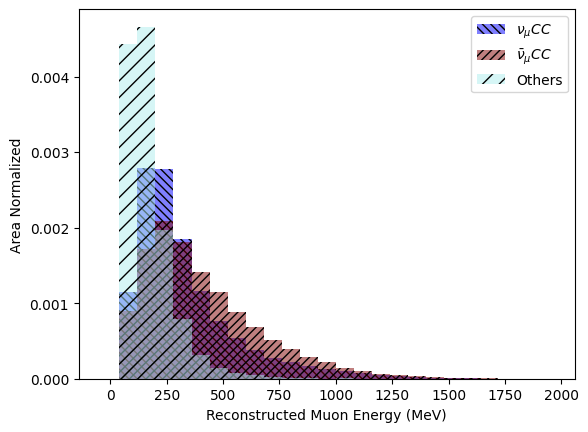

In [75]:
plt.hist(df_numucc['muon_energy']*1000, 25, (0.,2000.), density=True, label=r'$\nu_{\mu}CC$', align='left', alpha=.5, color='blue',hatch='\\\\\\\\')
plt.hist(df_numubar['muon_energy']*1000, 25, (0.,2000.), density=True, label= r'$\bar{\nu}_{\mu}CC$', align='left', alpha=.5, color='maroon',hatch='////')
plt.hist(df_others['muon_energy']*1000, 25, (0.,2000.), density=True, label= r'Others', align='left', alpha=.5, color='paleturquoise',hatch='//')
plt.xlabel("Reconstructed Muon Energy (MeV)")
plt.ylabel("Area Normalized")
plt.legend()
plt.show()

In [76]:
# # Prepare the data in the same binning (converted to MeV)
# data = [
#     df_others['reco_michel_energy'] * 1000,
#     df_numucc['reco_michel_energy'] * 1000,
#     df_numubar['reco_michel_energy'] * 1000
# ]

# # Define colors, labels, and hatches
# colors = ['paleturquoise', 'blue', 'maroon']
# labels = ['Others', r'$\nu_{\mu}CC$', r'$\bar{\nu}_{\mu}CC$']
# hatches = ['//', '\\\\\\\\', '////']

# # Plot stacked histogram
# n, bins, patches = plt.hist(
#     data,
#     bins=30,
#     range=(0., 100.),
#     stacked=True,
#     density=False,
#     color=colors,
#     label=labels,
#     align='left',
#     log=True
# )

# # Apply hatching
# for patch_set, hatch in zip(patches, hatches):
#     for bar in patch_set:
#         bar.set_hatch(hatch)

# plt.xlabel("Reconstructed Michel Electron Energy (MeV)")
# plt.ylabel("Events (Log-Scale)")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [77]:
# # Prepare the data in the same binning (converted to MeV)
# data = [
#     df_others['truth_michel_energy'] * 1000,
#     df_numucc['truth_michel_energy'] * 1000,
#     df_numubar['truth_michel_energy'] * 1000
# ]

# # Define colors, labels, and hatches
# colors = ['paleturquoise', 'blue', 'maroon']
# labels = ['Others', r'$\nu_{\mu}CC$', r'$\bar{\nu}_{\mu}CC$']
# hatches = ['//', '\\\\\\\\', '////']

# # Plot stacked histogram
# n, bins, patches = plt.hist(
#     data,
#     bins=30,
#     range=(0., 100.),
#     stacked=True,
#     density=False,
#     color=colors,
#     label=labels,
#     align='left',
#     log=True
# )

# # Apply hatching
# for patch_set, hatch in zip(patches, hatches):
#     for bar in patch_set:
#         bar.set_hatch(hatch)

# plt.xlabel("Truth Michel Electron Energy (MeV)")
# plt.ylabel("Events (Log-Scale)")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [78]:
# # Prepare the data in the same binning (converted to MeV)
# data = [
#     df_others['reco_michel_muon_costheta'],
#     df_numucc['reco_michel_muon_costheta'],
#     df_numubar['reco_michel_muon_costheta']
# ]

# # Define colors, labels, and hatches
# colors = ['paleturquoise', 'blue', 'maroon']
# labels = ['Others', r'$\nu_{\mu}CC$', r'$\bar{\nu}_{\mu}CC$']
# hatches = ['//', '\\\\\\\\', '////']

# # Plot stacked histogram
# n, bins, patches = plt.hist(
#     data,
#     bins=30,
#     range=(-1., 1.),
#     stacked=True,
#     density=False,
#     color=colors,
#     label=labels,
#     align='left',
#     log=False
# )

# # Apply hatching
# for patch_set, hatch in zip(patches, hatches):
#     for bar in patch_set:
#         bar.set_hatch(hatch)

# plt.xlabel(r"Reconstructed Michel-Muon cos($\theta$)")
# plt.ylabel("Events")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [79]:
# # Prepare the data in the same binning (converted to MeV)
# data = [
#     df_others['truth_michel_muon_costheta'],
#     df_numucc['truth_michel_muon_costheta'],
#     df_numubar['truth_michel_muon_costheta']
# ]

# # Define colors, labels, and hatches
# colors = ['paleturquoise', 'blue', 'maroon']
# labels = ['Others', r'$\nu_{\mu}CC$', r'$\bar{\nu}_{\mu}CC$']
# hatches = ['//', '\\\\\\\\', '////']

# # Plot stacked histogram
# n, bins, patches = plt.hist(
#     data,
#     bins=30,
#     range=(-1., 1.),
#     stacked=True,
#     density=False,
#     color=colors,
#     label=labels,
#     align='left',
#     log=False
# )

# # Apply hatching
# for patch_set, hatch in zip(patches, hatches):
#     for bar in patch_set:
#         bar.set_hatch(hatch)

# plt.xlabel(r"Truth Michel-Muon cos($\theta$)")
# plt.ylabel("Events")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [80]:
# fig = px.density_heatmap(df_numucc, x="truth_michel_muon_costheta", y="truth_michel_energy", text_auto=False,
#                          labels={"truth_michel_energy": "...", "truth_michel_muon_costheta": "cos (theta)"},
#                          marginal_x="histogram", marginal_y="histogram", title="numuCC proton multiplicity vs scattering angle",
#                          range_x=(-1.,1.), range_y=(0,0.1), nbinsx=100, nbinsy=100)
# fig.show()

## Plotting Proton Multiplicity and Scattering Angle Distribution

For numuCC label

In [81]:
fig = px.density_heatmap(df_numucc, x="cos_theta", y="Num_Proton", text_auto=False,
                         labels={"Num_Proton": "Proton Multiplicity", "cos_theta": "cos (theta)"},
                         marginal_x="histogram", marginal_y="histogram", title="numuCC proton multiplicity vs scattering angle",
                         range_x=(0.2,1.02), range_y=(-.2,3.), nbinsx=100, nbinsy=15)
fig.show()

In [82]:
fig = px.density_heatmap(df_numubar, x="cos_theta", y="Num_Proton", text_auto=False, 
                         labels={"Num_Proton": "Proton Multiplicity", "cos_theta": "cos(theta)"},
                         marginal_x="histogram", marginal_y="histogram", title="numubarCC proton multiplicity vs scattering angle",
                         range_x=(0.4,1.02), range_y=(-0.5,3.), nbinsx=75, nbinsy=10)
fig.show()

### **Applying the MC-trained BDT onto other samples (specifically data)**

In [83]:
#===============================================================#
# Apply trained FHC BDT to FHC analysis samples
#===============================================================#

def add_bdt_prediction_columns(df, model, training_variables):
    """
    Add multiclass BDT probability columns and the custom scalar BDT score.

    Class convention:
      0 = others
      1 = numuCC
      2 = numubarCC

    Custom score:
      score = -3*P(others) - P(numuCC) + P(numubarCC)
    """
    proba = model.predict_proba(prepare_bdt_features(df, training_variables))

    # Use model.classes_ instead of assuming column order blindly.
    class_to_col = {int(c): i for i, c in enumerate(model.classes_)}

    p_others  = proba[:, class_to_col[0]]
    p_numucc  = proba[:, class_to_col[1]]
    p_numubar = proba[:, class_to_col[2]]

    df.loc[:, "bdt_score_others"]    = p_others
    df.loc[:, "bdt_score_numucc"]    = p_numucc
    df.loc[:, "bdt_score_numubarcc"] = p_numubar

    df.loc[:, "bdt_score"] = -3.0*p_others - p_numucc + p_numubar

    return df


# DATA/EXT/DIRT were not used for BDT development, so keep all of them.
df_dataFC_FHC = add_bdt_prediction_columns(df_dataFC_FHC.copy(), clf, training_variables)
df_extFC_FHC  = add_bdt_prediction_columns(df_extFC_FHC.copy(),  clf, training_variables)
df_dirtFC_FHC = add_bdt_prediction_columns(df_dirtFC_FHC.copy(), clf, training_variables)

# MC overlay was used for BDT development only for odd event-run-number events.
# For the final analysis/application, keep only even event-run-number MC overlay.
df_mcFC_FHC_analysis = df_mcFC_FHC[df_mcFC_FHC["run"] % 2 == 0].copy()
df_mcFC_FHC_analysis = add_bdt_prediction_columns(df_mcFC_FHC_analysis, clf, training_variables)

print("RHC BDT application summary")
print("DATA entries:", len(df_dataFC_FHC))
print("EXT entries: ", len(df_extFC_FHC))
print("DIRT entries:", len(df_dirtFC_FHC))
print("MC original entries:", len(df_mcFC_FHC))
print("MC even-run analysis entries:", len(df_mcFC_FHC_analysis))
print("MC odd-run excluded entries:", len(df_mcFC_FHC) - len(df_mcFC_FHC_analysis))

RHC BDT application summary
DATA entries: 18923
EXT entries:  11610
DIRT entries: 2141
MC original entries: 185673
MC even-run analysis entries: 92654
MC odd-run excluded entries: 93019


### **For our BDT model, plot out the efficiency and purity of our signal**

In [84]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

In [85]:
# Get predicted probabilities for each class
probs_mc = clf.predict_proba(df_mcFC_FHC[training_variables])

# Create new columns for each class-specific BDT score
df_mcFC_FHC['bdt_score_others']  = probs_mc[:, 0]  # class 0 → others
df_mcFC_FHC['bdt_score_numu']    = probs_mc[:, 1]  # class 1 → νμCC
df_mcFC_FHC['bdt_score_numubar'] = probs_mc[:, 2]  # class 2 → ν̅μCC


In [86]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import numpy as np

def plot_eff_purity(df_mc, sig_label):
    step = 0.01
    bdt_var_min = 0.0
    # Set maximum BDT score based on signal label
    if sig_label == "numubar":
        bdt_var_max = 0.96
    elif sig_label == "numu":
        bdt_var_max = 0.965
    elif sig_label == "others":
        bdt_var_max = 0.93
    else:
        raise ValueError("Invalid signal label. Choose from: 'numubar', 'numu', 'others'.")


    # Select appropriate BDT score column
    if sig_label == "numubar":
        score = df_mc['bdt_score_numubar']
        signal_mask = (df_mc.truth_nuPdg == -14) & (df_mc.truth_isCC == 1) & (df_mc.truth_vtxInside == 1)
    elif sig_label == "numu":
        score = df_mc['bdt_score_numu']
        signal_mask = (df_mc.truth_nuPdg == 14) & (df_mc.truth_isCC == 1) & (df_mc.truth_vtxInside == 1)
    elif sig_label == "others":
        score = df_mc['bdt_score_others']
        signal_mask = (df_mc.truth_nuPdg != 14) & (df_mc.truth_nuPdg != -14) & (df_mc.truth_isCC == 1) & (df_mc.truth_vtxInside == 1)
    else:
        raise ValueError("sig_label must be 'numubar', 'numu', or 'others'")

    h_eff, h_eff_x = [], []
    h_pur, h_pur_x = [], []
    h_multi, h_multi_x = [], []

    thresholds = np.arange(bdt_var_min, bdt_var_max + step, step)
    for var in thresholds:
        # Efficiency
        df_eff_num = df_mc[signal_mask & (score > var)]
        df_eff_den = df_mc[signal_mask]
        if len(df_eff_den) != 0:
            eff = len(df_eff_num) / len(df_eff_den)
            h_eff.append(eff)
            h_eff_x.append(var)

        # Purity
        df_pur_den = df_mc[score > var]
        df_pur_num = df_eff_num  # already defined above
        if len(df_pur_den) != 0:
            pur = len(df_pur_num) / len(df_pur_den)
            h_pur.append(pur)
            h_pur_x.append(var)

            # Eff × Pur
            h_multi.append(pur * eff)
            h_multi_x.append(var)

    # Interpolate for intersection
    # f1 = interp1d(h_eff_x, h_eff, kind='linear', fill_value='extrapolate')
    # f2 = interp1d(h_pur_x, h_pur, kind='linear', fill_value='extrapolate')
    # def intersection(x): return f1(x) - f2(x)
    # guess = np.linspace(bdt_var_min, bdt_var_max, 10)
    # roots = fsolve(intersection, guess)
    # valid_roots = [r for r in roots if bdt_var_min <= r <= bdt_var_max]

    # Plotting
    plt.plot(h_eff_x, h_eff, c="green", label="Efficiency")
    plt.plot(h_pur_x, h_pur, c="purple", label="Purity")
    plt.plot(h_multi_x, h_multi, ls="-.", c="red", label=r"Eff. $\times$ Pur.")

    # if valid_roots:
    #     plt.axvline(valid_roots[0], color='blue', ls='--', label=f"Intersection at {valid_roots[0]:.3f}")

    plt.xlim([0, 1.0])  # Keep axis fixed to 1.0 even if data stops early
    plt.ylim([0, 1.1])
    titles = {
        "numubar": r"BDT Model $\bar{\nu}_{\mu}$",
        "numu":    r"BDT Model $\nu_{\mu}$",
        "others":  "BDT Model Background"
    }
    plt.title(f"{titles[sig_label]} Selection Efficiency & Purity")
    plt.xlabel("BDT Score")
    plt.ylabel("Fraction")
    plt.legend()
    plt.tight_layout()
    plt.show()


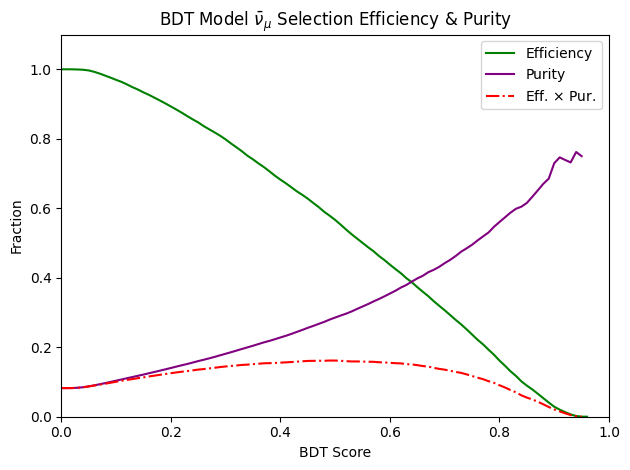

In [87]:
plot_eff_purity(df_mcFC_FHC, "numubar")

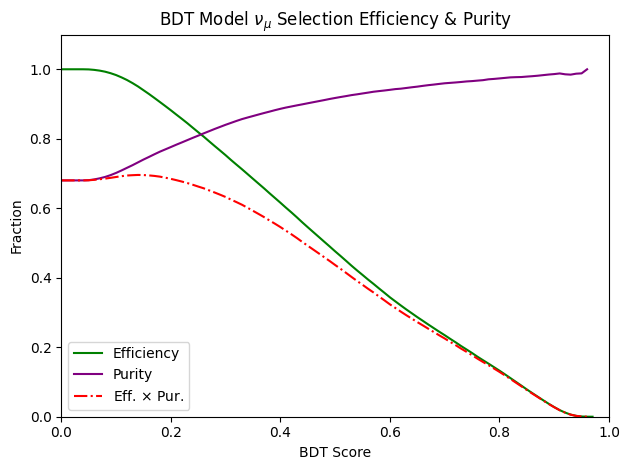

In [88]:
plot_eff_purity(df_mcFC_FHC, "numu")

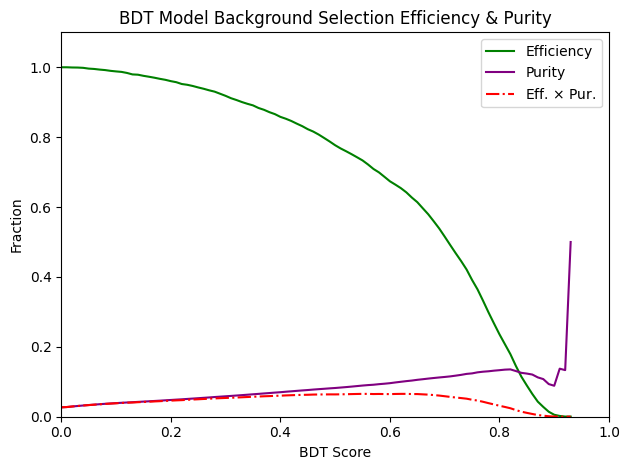

In [89]:
plot_eff_purity(df_mcFC_FHC, "others")

# EXPORT THE XGB MODEL AND GET IT READY FOR C API

In [90]:
# booster = clf.get_booster()        

# booster.save_model("bdt_multiclass.json")  # contains num_class, params, trees
# print("Saved model to bdt_multiclass.json")

In [91]:
import re
import xml.etree.cElementTree as ET
regex_float_pattern = r'[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?'

def build_tree(xgtree, base_xml_element, var_indices):
    parent_element_dict = {'0':base_xml_element}
    pos_dict = {'0':'s'}
    for line in xgtree.split('\n'):
        if not line: continue
        if ':leaf=' in line:
            #leaf node
            result = re.match(r'(\t*)(\d+):leaf=({0})$'.format(regex_float_pattern), line)
            if not result:
                print(line)
            depth = result.group(1).count('\t')
            inode = result.group(2)
            res = result.group(3)
            node_elementTree = ET.SubElement(parent_element_dict[inode], "Node", pos=str(pos_dict[inode]),
                                             depth=str(depth), NCoef="0", IVar="-1", Cut="0.0e+00", cType="1", res=str(res), rms="0.0e+00", purity="0.0e+00", nType="-99")
        else:
            #\t\t3:[var_topcand_mass<138.19] yes=7,no=8,missing=7
            result = re.match(r'(\t*)([0-9]+):\[(?P<var>.+)<(?P<cut>{0})\]\syes=(?P<yes>\d+),no=(?P<no>\d+)'.format(regex_float_pattern),line)
            if not result:
                print(line)
            depth = result.group(1).count('\t')
            inode = result.group(2)
            var = result.group('var')
            cut = result.group('cut')
            lnode = result.group('yes')
            rnode = result.group('no')
            pos_dict[lnode] = 'l'
            pos_dict[rnode] = 'r'
            node_elementTree = ET.SubElement(parent_element_dict[inode], "Node", pos=str(pos_dict[inode]),
                                             depth=str(depth), NCoef="0", IVar=str(var_indices[var]), Cut=str(cut),
                                             cType="1", res="0.0e+00", rms="0.0e+00", purity="0.0e+00", nType="0")
            parent_element_dict[lnode] = node_elementTree
            parent_element_dict[rnode] = node_elementTree

def convert_model(model, input_variables, output_xml):
    NTrees = len(model)
    var_list = input_variables
    var_indices = {}
    
    # <MethodSetup>
    MethodSetup = ET.Element("MethodSetup", Method="BDT::BDT")

    # <Variables>
    Variables = ET.SubElement(MethodSetup, "Variables", NVar=str(len(var_list)))
    for ind, val in enumerate(var_list):
        name = val[0]
        var_type = val[1]
        var_indices[name] = ind
        Variable = ET.SubElement(Variables, "Variable", VarIndex=str(ind), Type=val[1], 
            Expression=name, Label=name, Title=name, Unit="", Internal=name, 
            Min="0.0e+00", Max="0.0e+00")

    # <GeneralInfo>
    GeneralInfo = ET.SubElement(MethodSetup, "GeneralInfo")
    Info_Creator = ET.SubElement(GeneralInfo, "Info", name="Creator", value="xgboost2TMVA")
    Info_AnalysisType = ET.SubElement(GeneralInfo, "Info", name="AnalysisType", value="Classification")

    # <Options>
    Options = ET.SubElement(MethodSetup, "Options")
    Option_NodePurityLimit = ET.SubElement(Options, "Option", name="NodePurityLimit", modified="No").text = "5.00e-01"
    Option_BoostType = ET.SubElement(Options, "Option", name="BoostType", modified="Yes").text = "Grad"
    
    # <Weights>
    Weights = ET.SubElement(MethodSetup, "Weights", NTrees=str(NTrees), AnalysisType="1")
    
    for itree in range(NTrees):
        BinaryTree = ET.SubElement(Weights, "BinaryTree", type="DecisionTree", boostWeight="1.0e+00", itree=str(itree))
        build_tree(model[itree], BinaryTree, var_indices)
        
    tree = ET.ElementTree(MethodSetup)
    tree.write(output_xml)

In [92]:
#========================================================#
# Export 3-class XGBoost model into 3 TMVA XML files     #
#========================================================#

def export_multiclass_xgb_to_tmva_xmls(
    clf,
    training_variables,
    output_prefix,
    class_names=("others", "numuCC", "numubarCC"),
    use_best_iteration=True,
):
    n_classes = len(class_names)

    input_variables = [(var, "D") for var in training_variables]

    booster = clf.get_booster()
    booster.feature_names = training_variables

    model_dump = booster.get_dump(dump_format="text")

    n_total_trees = len(model_dump)

    if n_total_trees % n_classes != 0:
        raise ValueError(
            f"Total number of trees = {n_total_trees}, "
            f"but n_classes = {n_classes}."
        )

    n_rounds_total = n_total_trees // n_classes
    n_rounds_to_export = n_rounds_total

    if use_best_iteration and hasattr(booster, "best_iteration"):
        if booster.best_iteration is not None:
            n_rounds_to_export = booster.best_iteration + 1

    print("==========================================")
    print("Exporting multiclass XGBoost model to XML")
    print("==========================================")
    print(f"Total dumped trees:    {n_total_trees}")
    print(f"Total rounds:          {n_rounds_total}")
    print(f"Rounds exported:       {n_rounds_to_export}")
    print(f"Number of classes:     {n_classes}")
    print(f"Training variables:    {len(training_variables)}")
    print("==========================================")

    for iclass, class_name in enumerate(class_names):

        class_trees = [
            model_dump[iround * n_classes + iclass]
            for iround in range(n_rounds_to_export)
        ]

        output_xml = f"{output_prefix}_{class_name}.xml"

        print(
            f"Writing class {iclass} ({class_name}) "
            f"with {len(class_trees)} trees -> {output_xml}"
        )

        convert_model(
            class_trees,
            input_variables=input_variables,
            output_xml=output_xml,
        )

In [93]:
model_name = "wwang_numu_numubar_BDT_FHC"

export_multiclass_xgb_to_tmva_xmls(
    clf=clf,
    training_variables=training_variables,
    output_prefix="models/" + model_name,
    class_names=("others", "numuCC", "numubarCC"),
    use_best_iteration=True,
)

Exporting multiclass XGBoost model to XML
Total dumped trees:    1200
Total rounds:          400
Rounds exported:       399
Number of classes:     3
Training variables:    15
Writing class 0 (others) with 399 trees -> models/wwang_numu_numubar_BDT_FHC_others.xml


Writing class 1 (numuCC) with 399 trees -> models/wwang_numu_numubar_BDT_FHC_numuCC.xml
Writing class 2 (numubarCC) with 399 trees -> models/wwang_numu_numubar_BDT_FHC_numubarCC.xml


# TEMPLATE FIT CODE NEEDS TO BE UPDATED ACCORDINGLY AFTER EVEN/ODD SPLIT SAMPLING

# TEMPLATE FIT


In [94]:
# Use the full dataset
score_full = df_mcFC_FHC["bdt_score"].to_numpy()
w_full     = df_mcFC_FHC["weight_ubtune"].to_numpy()

# Masks from truth info in df_mc
mask_numub = (df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_numu  = (df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_bkg   = ~(mask_numu | mask_numub)

mask_bkg   = mask_bkg.to_numpy()
mask_numu  = mask_numu.to_numpy()
mask_numub = mask_numub.to_numpy()

# Histogram (FULL arrays, consistent length)
bins = np.linspace(-3, 1, 50) 
bin_centers = 0.5*(bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

hist_bkg,   _ = np.histogram(score_full[mask_bkg],   bins=bins, weights=w_full[mask_bkg])
hist_numu,  _ = np.histogram(score_full[mask_numu],  bins=bins, weights=w_full[mask_numu])
hist_numub, _ = np.histogram(score_full[mask_numub], bins=bins, weights=w_full[mask_numub])

# --- “data” for a self-check is just the sum of templates ---
data_hist = hist_bkg + hist_numu + hist_numub

# --- χ² to minimize (Poisson variance on data bins) ---
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg*hist_bkg + S_numu*hist_numu + S_numub*hist_numub
    err = np.sqrt(np.maximum(data_hist, 1.0))  # avoid zeros
    return np.sum(((data_hist - model)/err)**2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits = [(0, None), (0, None), (0, None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad(); m.hesse()

print("Best-fit scale factors (self-fit should be ~1):")
for p in ("S_bkg","S_numu","S_numub"):
    print(f"  {p} = {m.values[p]:.4f} ± {m.errors[p]:.4f}")
ndf = len(data_hist) - len(m.values)
print(f"chi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

# --- compare fit to “data” ---
best = (m.values["S_bkg"]*hist_bkg +
        m.values["S_numu"]*hist_numu +
        m.values["S_numub"]*hist_numub)

plt.step(bin_centers, data_hist, where="mid", color="k", label="Sum of 3 MC Classes")
plt.step(bin_centers, best,      where="mid", color="r", label="Minuit Fit")

# also show the MC components (stacked)
plt.bar(bin_centers, hist_bkg,   width=np.diff(bins), color="green", alpha=0.3, label="Others", align="center")
plt.bar(bin_centers, hist_numu,  width=np.diff(bins), bottom=hist_bkg, 
        color="blue", alpha=0.3, label=r'$\nu_{\mu}CC$', align="center")
plt.bar(bin_centers, hist_numub, width=np.diff(bins), bottom=hist_bkg+hist_numu, 
        color="red", alpha=0.3, label=r'$\bar{\nu}_{\mu}CC$', align="center")

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend(fontsize=8, frameon=False)
plt.show()


KeyError: 'bdt_score'

## Template Fitting to itself for non-composite numubarCC target score

Best-fit scale factors (self-fit should be ~1):
  S_bkg = 1.0000 ± 0.1177
  S_numu = 1.0000 ± 0.0402
  S_numub = 1.0000 ± 0.0851
chi2/ndf = 0.00 / 46 = 0.00


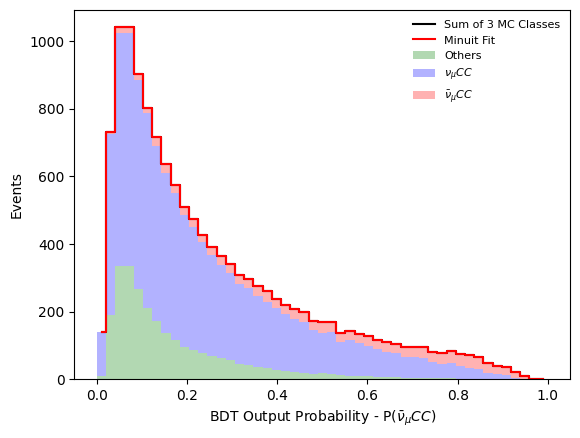

In [97]:
# Use the full dataset
score_full = df_mcFC_FHC["bdt_score_numubarcc"].to_numpy()
w_full     = df_mcFC_FHC["weight_ubtune"].to_numpy()

# Masks from truth info in df_mcFC_FHC
mask_numub = (df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_numu  = (df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_bkg   = ~(mask_numu | mask_numub)

mask_bkg   = mask_bkg.to_numpy()
mask_numu  = mask_numu.to_numpy()
mask_numub = mask_numub.to_numpy()

# Histogram for bdt_score_numubarcc: range 0 -> 1
bins = np.linspace(0, 1, 50)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

hist_bkg,   _ = np.histogram(score_full[mask_bkg],   bins=bins, weights=w_full[mask_bkg])
hist_numu,  _ = np.histogram(score_full[mask_numu],  bins=bins, weights=w_full[mask_numu])
hist_numub, _ = np.histogram(score_full[mask_numub], bins=bins, weights=w_full[mask_numub])

# “Data” for self-check = sum of templates
data_hist = hist_bkg + hist_numu + hist_numub

# χ² function
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg * hist_bkg + S_numu * hist_numu + S_numub * hist_numub
    err = np.sqrt(np.maximum(data_hist, 1.0))
    return np.sum(((data_hist - model) / err) ** 2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits = [(0, None), (0, None), (0, None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad()
m.hesse()

print("Best-fit scale factors (self-fit should be ~1):")
for p in ("S_bkg", "S_numu", "S_numub"):
    print(f"  {p} = {m.values[p]:.4f} ± {m.errors[p]:.4f}")

ndf = len(data_hist) - len(m.values)
print(f"chi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

# Best-fit model
best = (
    m.values["S_bkg"]  * hist_bkg +
    m.values["S_numu"] * hist_numu +
    m.values["S_numub"] * hist_numub
)

# Plot
plt.step(bin_centers, data_hist, where="mid", color="k", label="Sum of 3 MC Classes")
plt.step(bin_centers, best, where="mid", color="r", label="Minuit Fit")

plt.bar(bin_centers, hist_bkg, width=bin_widths, color="green", alpha=0.3,
        label="Others", align="center")
plt.bar(bin_centers, hist_numu, width=bin_widths, bottom=hist_bkg,
        color="blue", alpha=0.3, label=r'$\nu_{\mu}CC$', align="center")
plt.bar(bin_centers, hist_numub, width=bin_widths, bottom=hist_bkg + hist_numu,
        color="red", alpha=0.3, label=r'$\bar{\nu}_{\mu}CC$', align="center")

plt.xlabel(r'BDT Output Probability - P($\bar{\nu}_{\mu}CC$)')
plt.ylabel("Events")
plt.legend(fontsize=8, frameon=False)
plt.show()

### Assess the goodness of the fit but generating random and poisson flutuated data, and running toy study 100,000 times

In [98]:
# ============================
# Parameter-pull toy study
# ============================
N_toys = 100000
rng = np.random.default_rng(20250929)

# Use the full dataset
score_full = df_mcFC_FHC["bdt_score"].to_numpy()
w_full     = df_mcFC_FHC["weight_ubtune"].to_numpy()

# Masks from truth info in df_mc
mask_numub = (df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_numu  = (df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_bkg   = ~(mask_numu | mask_numub)

mask_bkg   = mask_bkg.to_numpy()
mask_numu  = mask_numu.to_numpy()
mask_numub = mask_numub.to_numpy()

# Histogram (FULL arrays, consistent length)
bins = np.linspace(-3, 1, 50) 
bin_centers = 0.5*(bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

hist_bkg,   _ = np.histogram(score_full[mask_bkg],   bins=bins, weights=w_full[mask_bkg])
hist_numu,  _ = np.histogram(score_full[mask_numu],  bins=bins, weights=w_full[mask_numu])
hist_numub, _ = np.histogram(score_full[mask_numub], bins=bins, weights=w_full[mask_numub])


# Set true scaling factors and then Poisson fluctuate them
S_true_bkg, S_true_numu, S_true_numub = 1., 1., 1.
S_true = {
    "S_bkg":   S_true_bkg, 
    "S_numu":  S_true_numu,
    "S_numub": S_true_numub,
}

def fit_one_toy(mu_expect):
    """Generate a Poisson toy from expected bin means and fit scale factors."""
    toy = rng.poisson(lam=np.maximum(mu_expect, 0.0))
    def chi2_toy(S_bkg, S_numu, S_numub):
        model = S_bkg*hist_bkg + S_numu*hist_numu + S_numub*hist_numub
        err = np.sqrt(np.maximum(toy, 1.0))
        return np.sum(((toy - model)/err)**2)
    mt = Minuit(chi2_toy, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
    mt.limits = [(0,None),(0,None),(0,None)]
    mt.errordef = Minuit.LEAST_SQUARES
    mt.migrad(); mt.hesse()
    return mt, toy

# Expected bin means under S_true
mu_true = (S_true["S_bkg"]  * hist_bkg +
           S_true["S_numu"] * hist_numu +
           S_true["S_numub"]* hist_numub)

pulls_params = {"S_bkg": [], "S_numu": [], "S_numub": []}
chi2_over_ndf = []

fit_vals = {"S_bkg": [], "S_numu": [], "S_numub": []}
fit_errs = {"S_bkg": [], "S_numu": [], "S_numub": []}
residual = {"S_bkg": [], "S_numu": [], "S_numub": []}  # S_fit - S_true


for _ in range(N_toys):
    mt, toy_hist = fit_one_toy(mu_true)
    
    ndf_toy = len(toy_hist) - 3
    chi2_over_ndf.append(mt.fval / ndf_toy)

    for par in ("S_bkg","S_numu","S_numub"):
        val = mt.values[par]
        err = mt.errors[par]

        # store for plotting
        fit_vals[par].append(val)
        fit_errs[par].append(err)
        residual[par].append(val - S_true[par])

        # proper pull: (fit - true) / sigma_fit
        if err > 0:
            pulls_params[par].append((val - S_true[par]) / err)


S_bkg: mean pull = -0.199, width = 1.010  (N=100000)
S_numu: mean pull = +0.009, width = 1.009  (N=100000)
S_numub: mean pull = -0.309, width = 1.028  (N=100000)
chi2/ndf: mean = 0.945, std = 0.206


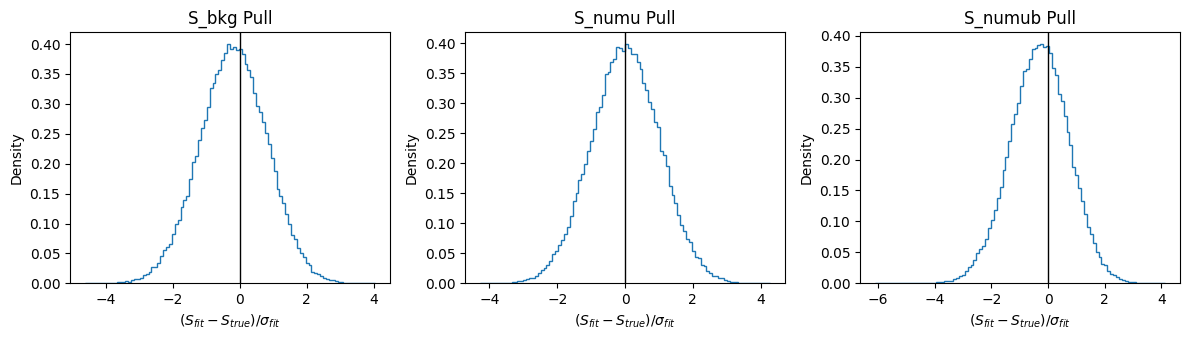

In [99]:
# Summaries
for par, arr in pulls_params.items():
    arr = np.asarray(arr)
    print(f"{par}: mean pull = {np.nanmean(arr):+.3f}, width = {np.nanstd(arr):.3f}  (N={len(arr)})")

print(f"chi2/ndf: mean = {np.mean(chi2_over_ndf):.3f}, std = {np.std(chi2_over_ndf):.3f}")

# Optional: visualize pull distributions
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), tight_layout=True)
for ax, (par, arr) in zip(axes, pulls_params.items()):
    ax.hist(arr, bins=100, histtype='step', density=True)
    ax.set_title(f"{par} Pull")
    ax.set_xlabel(r"$(S_{fit} - S_{true}) / \sigma_{fit}$")
    ax.set_ylabel("Density")
    ax.axvline(0, color='k', linewidth=1)
    # ax.axvline(+1, color='gray', linestyle='--', linewidth=1)
    # ax.axvline(-1, color='gray', linestyle='--', linewidth=1)
plt.show()

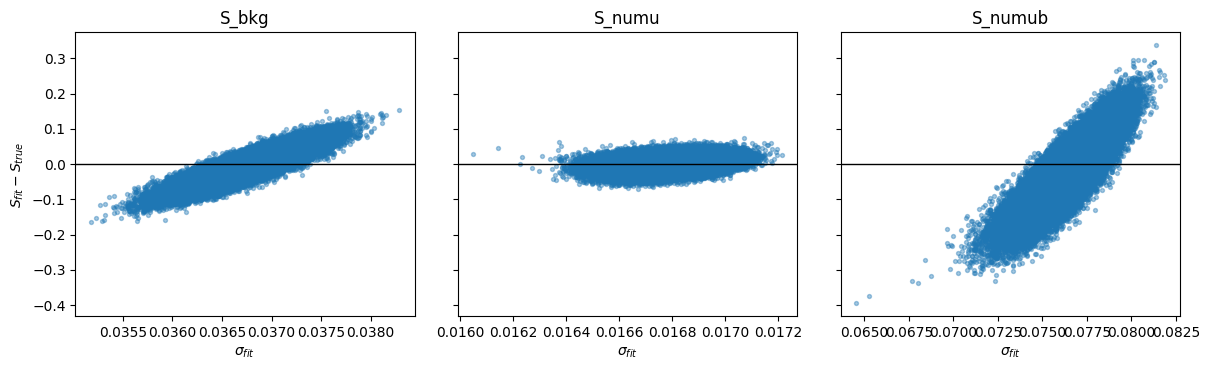

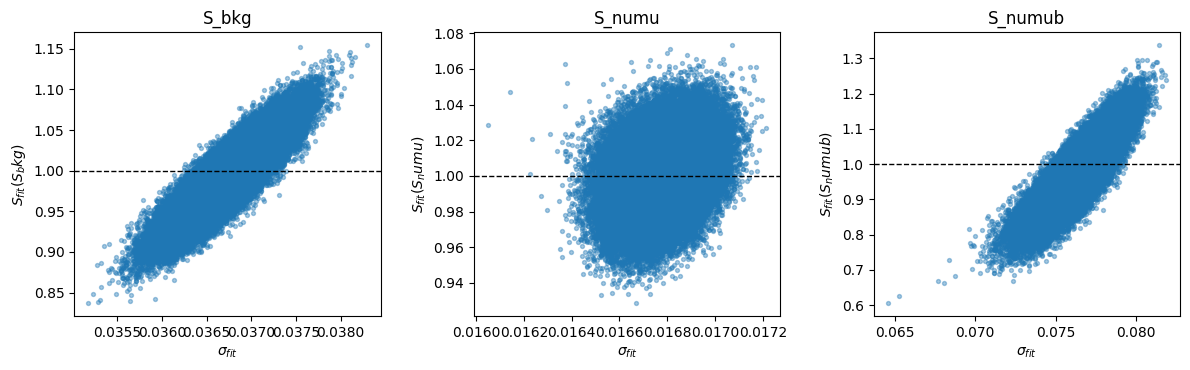

In [100]:
# ---------- Convert to arrays ----------
for d in (fit_vals, fit_errs, residual, pulls_params):
    for k in d:
        d[k] = np.asarray(d[k])

# ---------- Plot 1: (S_fit - S_true) vs sigma_fit ----------
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), tight_layout=True, sharey=True)
for ax, par in zip(axes, ("S_bkg","S_numu","S_numub")):
    ax.scatter(fit_errs[par], residual[par], s=8, alpha=0.4)
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel(rf"$\sigma_{{fit}}$")
    ax.set_title(rf"{par}")
axes[0].set_ylabel(r"$S_{fit}-S_{true}$")
plt.show()

# ---------- Plot 2: S_fit vs sigma_fit ----------
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), tight_layout=True, sharey=False)
for ax, par in zip(axes, ("S_bkg","S_numu","S_numub")):
    ax.scatter(fit_errs[par], fit_vals[par], s=8, alpha=0.4)
    ax.axhline(S_true[par], color="k", lw=1, ls="--", label="S_true=1")
    ax.set_xlabel(rf"$\sigma_{{fit}}$")
    ax.set_ylabel(rf"$S_{{fit}}({par})$")
    ax.set_title(rf"{par}")
plt.show()


In [101]:
def run_one_toy(S_true=(1.0, 1.0, 1.0), seed=None):
    # --- Build templates from df_mc (ubtune weights) ---
    score = df_mcFC_FHC["bdt_score"].to_numpy()
    w_nom = df_mcFC_FHC["weight_ubtune"].to_numpy()

    mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
    mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
    mask_bkg   = ~(mask_numu | mask_numub)

    bins = np.linspace(-3, 1, 50)
    bin_centers = 0.5*(bins[1:] + bins[:-1])
    bin_widths  = np.diff(bins)

    hist_bkg,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_nom[mask_bkg])
    hist_numu,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_nom[mask_numu])
    hist_numub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_nom[mask_numub])

    # --- Make one Poisson toy around S_true ---
    S_bkg_true, S_numu_true, S_numub_true = S_true
    mu = (S_bkg_true*hist_bkg + S_numu_true*hist_numu + S_numub_true*hist_numub)

    rng = np.random.default_rng(seed)
    data_hist = rng.poisson(lam=np.maximum(mu, 0.0))
    yerr = np.sqrt(np.maximum(data_hist, 1.0))

    # --- Fit with iminuit (χ² with data stat errors) ---
    def chi2(S_bkg, S_numu, S_numub):
        model = S_bkg*hist_bkg + S_numu*hist_numu + S_numub*hist_numub
        return np.sum(((data_hist - model)/yerr)**2)

    m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
    m.limits = [(0,None), (0,None), (0,None)]
    m.errordef = Minuit.LEAST_SQUARES
    m.migrad(); m.hesse()

    # --- Best-fit model & components ---
    best       = (m.values["S_bkg"]*hist_bkg + m.values["S_numu"]*hist_numu + m.values["S_numub"]*hist_numub)
    best_bkg   = m.values["S_bkg"]  * hist_bkg
    best_numu  = m.values["S_numu"] * hist_numu
    best_numub = m.values["S_numub"]* hist_numub

    # --- Print results ---
    ndf = len(data_hist) - 3
    print("True SFs:", f"S_bkg={S_bkg_true:.3f}, S_numu={S_numu_true:.3f}, S_numub={S_numub_true:.3f}")
    for p in ("S_bkg","S_numu","S_numub"):
        print(f"{p} = {m.values[p]:.4f} ± {m.errors[p]:.4f}")
    print(f"chi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

    # --- Plot ---
    plt.figure(figsize=(7.2,5.2))

    # show unscaled templates in background (optional; comment out if you like)
    plt.bar(bins[:-1], hist_bkg,   width=bin_widths, color="green", alpha=0.25,
            label="Bkg (ubtune)", align="edge", edgecolor="none", zorder=1)
    plt.bar(bins[:-1], hist_numu,  width=bin_widths, bottom=hist_bkg,
            color="blue",  alpha=0.25, label=r"$\nu_\mu$CC (ubtune)", align="edge", edgecolor="none", zorder=1)
    plt.bar(bins[:-1], hist_numub, width=bin_widths, bottom=hist_bkg+hist_numu,
            color="red",   alpha=0.25, label=r"$\bar{\nu}_\mu$CC (ubtune)", align="edge", edgecolor="none", zorder=1)

    # best-fit total (solid red) and components (dashed red)
    plt.step(bin_centers, best, where="mid", color="r", linewidth=1.6, label="Best-fit total", zorder=2)
    plt.step(bin_centers, best_bkg,   where="mid", color="r", linestyle="--", dashes=(4,2),  linewidth=1.1, label="Best-fit bkg",   zorder=2)
    plt.step(bin_centers, best_numu,  where="mid", color="r", linestyle="--", dashes=(2,2),  linewidth=1.1, label=r"Best-fit $\nu_\mu$CC",   zorder=2)
    plt.step(bin_centers, best_numub, where="mid", color="r", linestyle="--", dashes=(6,2,2,2), linewidth=1.1, label=r"Best-fit $\bar{\nu}_\mu$CC", zorder=2)

    # data as black step + error bars
    plt.step(bin_centers, data_hist, where="mid", color="k", linewidth=1.4, label="Toy data", zorder=3)
    plt.errorbar(bin_centers, data_hist, yerr=yerr, fmt='none', ecolor='k', elinewidth=1, capsize=2, zorder=3)

    plt.xlabel("BDT score"); plt.ylabel("Events")
    #plt.title("One Poisson toy: fit to ubtune templates")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

True SFs: S_bkg=1.000, S_numu=1.000, S_numub=1.000
S_bkg = 1.0251 ± 0.0369
S_numu = 0.9905 ± 0.0167
S_numub = 0.9319 ± 0.0762
chi2/ndf = 47.93 / 46 = 1.04


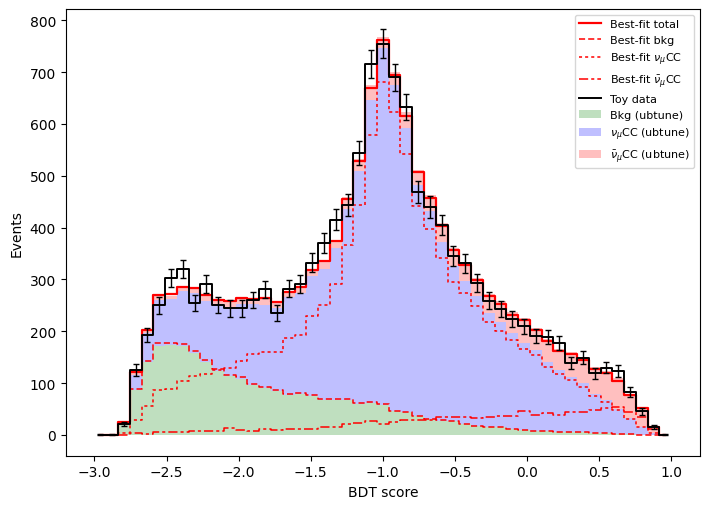

In [102]:
# Example: run one toy with S_true=(1,1,1) and a fixed seed
run_one_toy(S_true=(1.0, 1.0, 1.0), seed=12345)


Covariance:
 ┌─────────┬───────────────────────────────┐
│         │     S_bkg    S_numu   S_numub │
├─────────┼───────────────────────────────┤
│   S_bkg │  9.53e-05 -0.022e-3   0.03e-3 │
│  S_numu │ -0.022e-3  1.92e-05 -0.050e-3 │
│ S_numub │   0.03e-3 -0.050e-3  0.000404 │
└─────────┴───────────────────────────────┘
Corr matrix:
 ┌─────────┬─────────────────────────┐
│         │   S_bkg  S_numu S_numub │
├─────────┼─────────────────────────┤
│   S_bkg │       1    -0.5     0.1 │
│  S_numu │    -0.5       1    -0.6 │
│ S_numub │     0.1    -0.6       1 │
└─────────┴─────────────────────────┘
Fitted scale factors (data = weight_no_ubtune, templates = weight_ubtune):
  S_bkg = 0.9697 ± 0.0098
  S_numu = 0.8915 ± 0.0044
  S_numub = 0.9151 ± 0.0201

chi2/ndf = 24.22 / 46 = 0.53


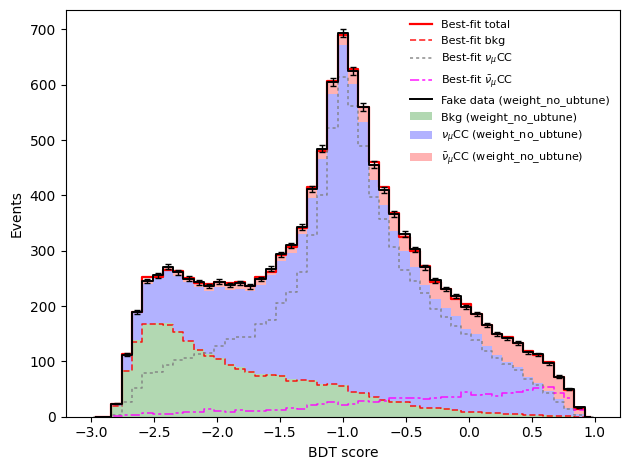

In [103]:
# ------------------------------------------------------------
# Use the full dataset
# ------------------------------------------------------------
score_full = df_mcFC_FHC["bdt_score"].to_numpy()
w_nominal  = df_mcFC_FHC["weight_ubtune"].to_numpy()     # MC model (templates)
w_fake     = df_mcFC_FHC["weight_no_ubtune"].to_numpy()  # treated as "data"

# Masks from truth info in df_mc
mask_numub = (df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_numu  = (df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)
mask_bkg   = ~(mask_numu | mask_numub)

mask_bkg   = mask_bkg.to_numpy()
mask_numu  = mask_numu.to_numpy()
mask_numub = mask_numub.to_numpy()

# ------------------------------------------------------------
# Histogram binning
# ------------------------------------------------------------
bins = np.linspace(-3, 1, 50) 
bin_centers = 0.5*(bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

# Nominal templates (ubtune weights)
hist_bkg,   _ = np.histogram(score_full[mask_bkg],   bins=bins, weights=w_nominal[mask_bkg])
hist_numu,  _ = np.histogram(score_full[mask_numu],  bins=bins, weights=w_nominal[mask_numu])
hist_numub, _ = np.histogram(score_full[mask_numub], bins=bins, weights=w_nominal[mask_numub])

hist_bkg_no_ubtune,   _ = np.histogram(score_full[mask_bkg],   bins=bins, weights=w_fake[mask_bkg])
hist_numu_no_ubtune,  _ = np.histogram(score_full[mask_numu],  bins=bins, weights=w_fake[mask_numu])
hist_numub_no_ubtune, _ = np.histogram(score_full[mask_numub], bins=bins, weights=w_fake[mask_numub])

# Fake "data" histogram (no_ubtune weights)
data_hist, _ = np.histogram(score_full, bins=bins, weights=w_fake)

# Corresponding statistical variance = sum of w^2 in each bin
data_var, _  = np.histogram(score_full, bins=bins, weights=w_fake**2)
yerr = np.sqrt(np.maximum(data_var, 1e-12))  # avoid zeros

# ------------------------------------------------------------
# Chi^2 fit with iminuit
# ------------------------------------------------------------
# Use the same yerr in the chi2, too:
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg*hist_bkg + S_numu*hist_numu + S_numub*hist_numub
    err = np.maximum(yerr, 1e-12)
    return np.sum(((data_hist - model)/err)**2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits = [(0, None), (0, None), (0, None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad(); m.hesse()
print("Covariance:\n", m.covariance)           # variances on diagonal
print("Corr matrix:\n", m.covariance.correlation())


best = (m.values["S_bkg"]*hist_bkg +
        m.values["S_numu"]*hist_numu +
        m.values["S_numub"]*hist_numub)

ndf = len(data_hist) - 3

print("Fitted scale factors (data = weight_no_ubtune, templates = weight_ubtune):")
for p in ("S_bkg","S_numu","S_numub"):
    val, err = m.values[p], m.errors[p]
    print(f"  {p} = {val:.4f} ± {err:.4f}")
print(f"\nchi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

# Templates in background
plt.bar(bins[:-1], hist_bkg_no_ubtune,   width=bin_widths, color="green", alpha=0.30,
        label="Bkg (weight_no_ubtune)", align="edge", edgecolor="none", zorder=1)
plt.bar(bins[:-1], hist_numu_no_ubtune,  width=bin_widths, bottom=hist_bkg_no_ubtune,
        color="blue",  alpha=0.30, label=r"$\nu_\mu$CC (weight_no_ubtune)", align="edge", edgecolor="none", zorder=1)
plt.bar(bins[:-1], hist_numub_no_ubtune, width=bin_widths, bottom=hist_bkg_no_ubtune+hist_numu_no_ubtune,
        color="red",   alpha=0.30, label=r"$\bar{\nu}_\mu$CC (weight_no_ubtune)", align="edge", edgecolor="none", zorder=1)

# --- Best-fit model (solid red total) ---
plt.step(bin_centers, best, where="mid", color="r", linewidth=1.6,
         label="Best-fit total", zorder=2)

# --- Dashed red components (each scaled by its fitted SF) ---
best_bkg   = m.values["S_bkg"]  * hist_bkg
best_numu  = m.values["S_numu"] * hist_numu
best_numub = m.values["S_numub"]* hist_numub

plt.step(bin_centers, best_bkg,   where="mid", color="red", linestyle="-",
         dashes=(4,2), linewidth=1.1, alpha=0.9, label="Best-fit bkg",   zorder=2)
plt.step(bin_centers, best_numu,  where="mid", color="gray", linestyle="--",
         dashes=(2,2), linewidth=1.1, alpha=0.9, label=r"Best-fit $\nu_\mu$CC",   zorder=2)
plt.step(bin_centers, best_numub, where="mid", color="magenta", linestyle="--",
         dashes=(6,2,2,2), linewidth=1.1, alpha=0.9, label=r"Best-fit $\bar{\nu}_\mu$CC", zorder=2)


# "Data" from no_ubtune
plt.step(bin_centers, data_hist, where="mid", color="k", linewidth=1.4, label="Fake data (weight_no_ubtune)", zorder=3)
plt.errorbar(bin_centers, data_hist, yerr=yerr, fmt='none', ecolor='k',
             elinewidth=1, capsize=2, zorder=3)

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


## Randomly draw scaling factors and repeat toy study

S_bkg: mean diff=-6.634e-06, RMS=9.266e-05, slope=1.0001
S_numu: mean diff=+4.069e-06, RMS=4.377e-05, slope=1.0001
S_numub: mean diff=-3.672e-05, RMS=1.783e-04, slope=1.0002
χ²/ndf: mean=0.000, std=0.000


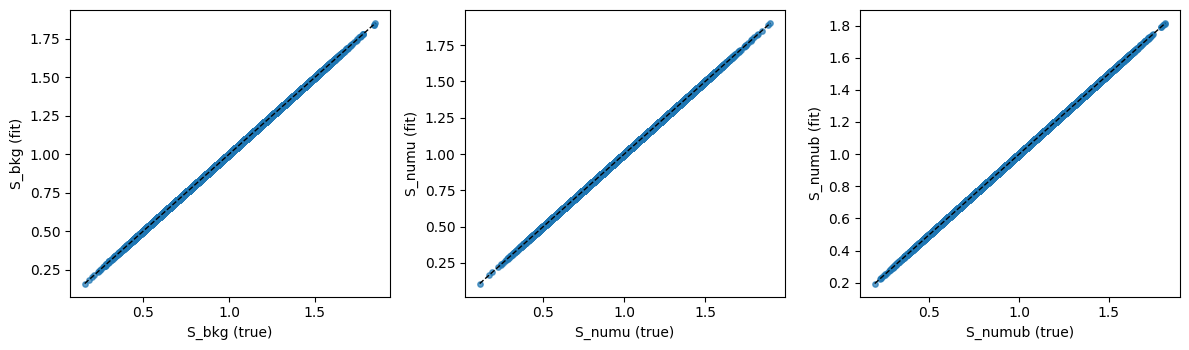

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# 1) Precompute templates
score = df_mcFC_FHC["bdt_score"].to_numpy()
w_nom = df_mcFC_FHC["weight_ubtune"].to_numpy()

mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_bkg   = ~(mask_numu | mask_numub)

bins = np.linspace(-3, 1, 50)
T_bkg,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_nom[mask_bkg])
T_numu,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_nom[mask_numu])
T_numub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_nom[mask_numub])

# 2) Toy setup
N_toys = 100000
rng = np.random.default_rng(12345)

true_S  = np.zeros((N_toys, 3))
fit_S   = np.zeros((N_toys, 3))
fit_err = np.zeros((N_toys, 3))
chi2ndf = np.zeros(N_toys)

for i in range(N_toys):
    # Draw true scale factors (e.g. Gaussian around 1)
    S_true = rng.normal(loc=1.0, scale=0.2, size=3)
    true_S[i] = S_true

    # Build exact deterministic “data” (no Poisson)
    toy = S_true[0]*T_bkg + S_true[1]*T_numu + S_true[2]*T_numub
    yerr = np.sqrt(np.maximum(toy, 1.0))   # just a placeholder for χ² denominator

    # Define χ² and fit
    def chi2(S_bkg, S_numu, S_numub):
        model = S_bkg*T_bkg + S_numu*T_numu + S_numub*T_numub
        return np.sum(((toy - model)/yerr)**2)

    m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
    m.limits = [(0,None),(0,None),(0,None)]
    m.errordef = Minuit.LEAST_SQUARES
    m.migrad(); m.hesse()

    fit_S[i]   = [m.values["S_bkg"], m.values["S_numu"], m.values["S_numub"]]
    fit_err[i] = [m.errors["S_bkg"], m.errors["S_numu"], m.errors["S_numub"]]
    chi2ndf[i] = m.fval / (len(toy) - 3)

# 3) Diagnostics
names = ["S_bkg","S_numu","S_numub"]
for k, name in enumerate(names):
    diff = fit_S[:,k] - true_S[:,k]
    slope = np.polyfit(true_S[:,k], fit_S[:,k], 1)[0]
    print(f"{name}: mean diff={np.mean(diff):+.3e}, RMS={np.std(diff):.3e}, slope={slope:.4f}")

print(f"χ²/ndf: mean={np.mean(chi2ndf):.3f}, std={np.std(chi2ndf):.3f}")

# 4) Fit-vs-True plot
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(true_S[:,k], fit_S[:,k], s=15, alpha=0.7)
    ax.plot([min(true_S[:,k]), max(true_S[:,k])],
            [min(true_S[:,k]), max(true_S[:,k])],
            'k--', lw=1)
    ax.set_xlabel(f"{name} (true)")
    ax.set_ylabel(f"{name} (fit)")
plt.show()


Toy #0 true scale factors:
  S_bkg   = 0.715
  S_numu  = 1.253
  S_numub = 0.826

Fitted scale factors:
  S_bkg = 0.7152 ± 0.0358
  S_numu = 1.2527 ± 0.0178
  S_numub = 0.8253 ± 0.0783


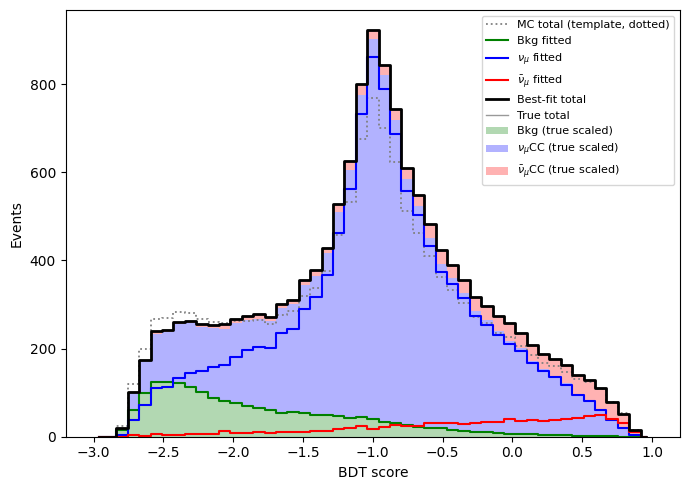

In [105]:
# Pick one toy to visualize
i_plot = 0  # change to visualize different toy index

# Retrieve the random true scale factors for this toy
S_true = true_S[i_plot]
print(f"Toy #{i_plot} true scale factors:")
print(f"  S_bkg   = {S_true[0]:.3f}")
print(f"  S_numu  = {S_true[1]:.3f}")
print(f"  S_numub = {S_true[2]:.3f}")

# Rebuild the "data" histogram for this toy
toy_hist = S_true[0]*T_bkg + S_true[1]*T_numu + S_true[2]*T_numub

# Refit this toy (so we can plot the fitted model)
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg*T_bkg + S_numu*T_numu + S_numub*T_numub
    err = np.sqrt(np.maximum(toy_hist, 1.0))
    return np.sum(((toy_hist - model)/err)**2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits = [(0,None),(0,None),(0,None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad(); m.hesse()

print("\nFitted scale factors:")
for p in ("S_bkg","S_numu","S_numub"):
    print(f"  {p} = {m.values[p]:.4f} ± {m.errors[p]:.4f}")

# Rebuild the fitted model and its components
best = (m.values["S_bkg"]*T_bkg +
        m.values["S_numu"]*T_numu +
        m.values["S_numub"]*T_numub)

# Also show individual fitted components (dashed)
bkg_fit   = m.values["S_bkg"]*T_bkg
numu_fit  = m.values["S_numu"]*T_numu
numub_fit = m.values["S_numub"]*T_numub

# --- precompute totals ---
T_tot   = T_bkg + T_numu + T_numub              # nominal MC total (dotted reference)
true_b  = S_true[0]*T_bkg
true_nu = S_true[1]*T_numu
true_nb = S_true[2]*T_numub
true_tot = true_b + true_nu + true_nb

bkg_fit   = m.values["S_bkg"]  * T_bkg
numu_fit  = m.values["S_numu"] * T_numu
numub_fit = m.values["S_numub"]* T_numub
best      = bkg_fit + numu_fit + numub_fit

# --- PLOT ---
plt.figure(figsize=(7,5))
bin_centers = 0.5*(bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

S_b, S_nu, S_nb = S_true 
true_bkg   = S_b  * T_bkg
true_numu  = S_nu * T_numu
true_numub = S_nb * T_numub

# 1) Dotted **total nominal template** (sum of categories)
plt.step(bin_centers, T_tot, where="mid", color="gray", linestyle=":",
         linewidth=1.3, label="MC total (template, dotted)")

# 2) True-scaled components as stacked fills (alpha=0.6)
plt.bar(bins[:-1], true_bkg,  width=bin_widths, color="green", alpha=0.30,
        align="edge", edgecolor="none", label="Bkg (true scaled)")

plt.bar(bins[:-1], true_numu, width=bin_widths, bottom=true_bkg,
        color="blue",  alpha=0.30, align="edge", edgecolor="none", label=r"$\nu_\mu$CC (true scaled)")

plt.bar(bins[:-1], true_numub, width=bin_widths, bottom=true_bkg+true_numu,
        color="red",   alpha=0.30, align="edge", edgecolor="none", label=r"$\bar{\nu}_\mu$CC (true scaled)")


# 3) Fitted components (solid)
plt.step(bin_centers, bkg_fit,   where="mid", color="green", linewidth=1.5, label="Bkg fitted")
plt.step(bin_centers, numu_fit,  where="mid", color="blue",  linewidth=1.5, label=r"$\nu_\mu$ fitted")
plt.step(bin_centers, numub_fit, where="mid", color="red",   linewidth=1.5, label=r"$\bar{\nu}_\mu$ fitted")

# 4) Totals (keep both if you want)
plt.step(bin_centers, best,      where="mid", color="k", linewidth=2.0, label="Best-fit total")
# (optional) overlay the true total as thin black
plt.step(bin_centers, true_tot,  where="mid", color="k", linewidth=1.0, alpha=0.4, label="True total")

plt.xlabel("BDT score"); plt.ylabel("Events")
plt.legend(fontsize=8, ncol=1)
plt.tight_layout()
plt.show()


## Combine the two different "fake data" pull study

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# -----------------------
# 0) Templates from df_mc
# -----------------------
score = df_mcFC_FHC["bdt_score"].to_numpy()
w_nom = df_mcFC_FHC["weight_ubtune"].to_numpy()

mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_bkg   = ~(mask_numu | mask_numub)

bins = np.linspace(-3, 1, 50)
bin_centers = 0.5*(bins[1:]+bins[:-1])
bin_widths  = np.diff(bins)

T_bkg,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_nom[mask_bkg])
T_numu,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_nom[mask_numu])
T_numub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_nom[mask_numub])

# -----------------------
# 1) Toy configuration
# -----------------------
N_toys = 100000
rng    = np.random.default_rng(20250929)
sig_draw = np.array([0.20, 0.20, 0.20])  # Gaussian draws around 1.0

# storage
true_S  = np.zeros((N_toys, 3))
fit_S   = np.zeros((N_toys, 3))
fit_err = np.zeros((N_toys, 3))
pulls   = np.zeros((N_toys, 3))
chi2ndf = np.zeros(N_toys)

# calibration constants (moved outside loop)
pars = ("S_bkg","S_numu","S_numub")
cal = {
    "S_bkg":   dict(a=-1.4406e-02, b=0.9988, width=1.023, mean_pull=-0.327),
    "S_numu":  dict(a=+7.4197e-04, b=1.0010, width=1.013, mean_pull=+0.066),
    "S_numub": dict(a=-3.5554e-02, b=1.0001, width=1.048, mean_pull=-0.434),
}

# -----------------------
# 2) Run toys
# -----------------------
for i in range(N_toys):
    # (a) draw random "true" scale factors
    S_true = rng.normal(loc=1.0, scale=sig_draw, size=3)
    S_true = np.clip(S_true, 0.0, None)
    true_S[i] = S_true

    # (b) build toy data
    mu  = S_true[0]*T_bkg + S_true[1]*T_numu + S_true[2]*T_numub
    toy = rng.poisson(lam=np.maximum(mu, 0.0))
    yerr = np.sqrt(np.maximum(toy, 1.0))

    # (c) fit with Minuit
    def chi2(S_bkg, S_numu, S_numub):
        model = S_bkg*T_bkg + S_numu*T_numu + S_numub*T_numub
        return np.sum(((toy - model)/yerr)**2)

    m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
    m.limits  = [(0,None),(0,None),(0,None)]
    m.errordef = Minuit.LEAST_SQUARES
    m.migrad(); m.hesse()

    # (d) calibration corrections
    fit_raw = np.array([m.values[p] for p in pars])
    err_raw = np.array([m.errors[p] for p in pars])

    fit_corr  = np.zeros(3)
    err_corr  = np.zeros(3)
    pull_corr = np.zeros(3)

    for k, p in enumerate(pars):
        a = cal[p]["a"]; b = cal[p]["b"]; w = cal[p]["width"]; mu_pull = cal[p]["mean_pull"]

        # linearity de-bias
        # S_cal   = (fit_raw[k] - a) / b
        # sig_cal =  err_raw[k] / abs(b)      # <-- pre-width sigma (same definition used to measure mean_pull)
        S_cal   = fit_raw[k]
        sig_cal = err_raw[k]

        # central-value correction using mean pull (in σ units) -- use sig_cal here
        S_corr_pre = S_cal - mu_pull * sig_cal

        # coverage correction (scale the 1σ)
        sig_final = w * sig_cal

        # final corrected central value and error
        S_corr  = S_corr_pre
        sigma   = sig_final

        fit_corr[k]  = S_corr
        err_corr[k]  = sigma
        pull_corr[k] = (S_corr - S_true[k]) / (sigma if sigma > 0 else np.nan)



    # store corrected results
    fit_S[i,:]   = fit_corr
    fit_err[i,:] = err_corr
    pulls[i,:]   = pull_corr

    # chi2/ndf from the raw fit (model vs toy), OK to keep as-is
    ndf = len(toy) - 3
    chi2ndf[i] = m.fval / ndf
for j,name in enumerate(("S_bkg","S_numu","S_numub")):
    print(f"{name}: mean={np.nanmean(pulls[:,j]):+.5f}, width={np.nanstd(pulls[:,j]):.5f}")

KeyboardInterrupt: 

In [ ]:
names = ["S_bkg","S_numu","S_numub"]
for k, name in enumerate(names):
    mean_pull = np.nanmean(pulls[:,k])
    width_pull = np.nanstd(pulls[:,k])
    print(f"{name}: mean pull = {mean_pull:+.3f}, width = {width_pull:.3f}  (N={np.isfinite(pulls[:,k]).sum()})")
print(f"chi2/ndf: mean = {np.mean(chi2ndf):.3f}, std = {np.std(chi2ndf):.3f}")

S_bkg: mean pull = +0.110, width = 0.991  (N=100000)
S_numu: mean pull = -0.078, width = 0.993  (N=100000)
S_numub: mean pull = +0.146, width = 0.977  (N=100000)
chi2/ndf: mean = 0.955, std = 0.206


In [ ]:
print("\n=== Summary: Bias and Resolution ===")
for k, name in enumerate(["S_bkg", "S_numu", "S_numub"]):
    diff = fit_S[:, k] - true_S[:, k]
    mean_diff = np.mean(diff)
    rms_diff  = np.std(diff)
    mean_sigma = np.mean(fit_err[:, k])
    coeff = np.polyfit(true_S[:,k], fit_S[:,k], deg=1)
    slope, intercept = coeff[0], coeff[1]
    print(f"{name}: mean diff = {mean_diff:+.4e}, RMS = {rms_diff:.4e}, <σ_fit> = {mean_sigma:.4e}, slope = {slope:.4f}, intercept = {intercept:+.4e}")



=== Summary: Bias and Resolution ===
S_bkg: mean diff = +4.4009e-03, RMS = 3.6548e-02, <σ_fit> = 3.6764e-02, slope = 1.0028, intercept = +1.6137e-03
S_numu: mean diff = -1.2434e-03, RMS = 1.6495e-02, <σ_fit> = 1.6572e-02, slope = 1.0000, intercept = -1.2127e-03
S_numub: mean diff = +1.2406e-02, RMS = 7.4905e-02, <σ_fit> = 7.6428e-02, slope = 1.0071, intercept = +5.2752e-03


In [ ]:
print("\n=== Mean fitted S_i across all toys ===")
names = ["S_bkg", "S_numu", "S_numub"]

for k, name in enumerate(names):
    mean_val = np.mean(fit_S[:, k])
    std_val  = np.std(fit_S[:, k])
    mean_true = np.mean(true_S[:, k]) if 'true_S' in locals() else 1.0
    print(f"{name}: ⟨S_fit⟩ = {mean_val:.4f} ± {std_val:.4f}   (⟨S_true⟩ = {mean_true:.4f})")



=== Mean fitted S_i across all toys ===
S_bkg: ⟨S_fit⟩ = 1.0043 ± 0.2039   (⟨S_true⟩ = 0.9999)
S_numu: ⟨S_fit⟩ = 0.9990 ± 0.2004   (⟨S_true⟩ = 1.0002)
S_numub: ⟨S_fit⟩ = 1.0131 ± 0.2152   (⟨S_true⟩ = 1.0007)


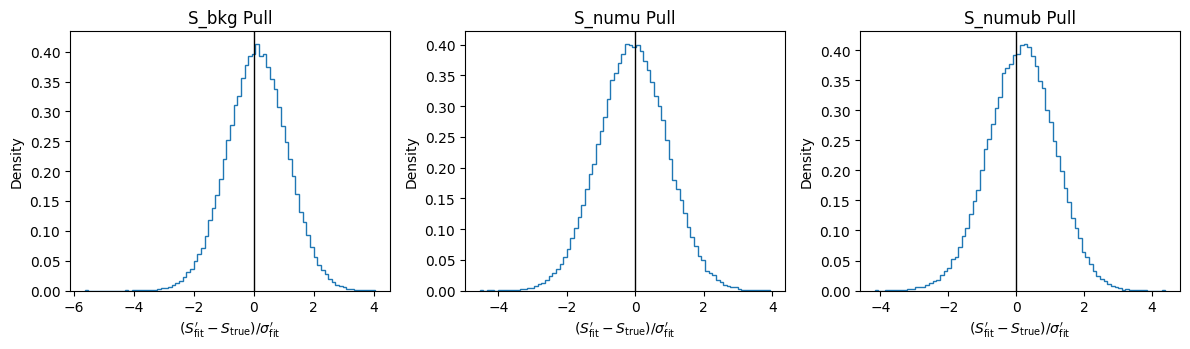

In [ ]:
# (A) Pull histograms
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.hist(pulls[:,k][np.isfinite(pulls[:,k])], bins=80, histtype='step', density=True)
    ax.axvline(0, color='k', lw=1)
    ax.set_title(f"{name} Pull")
    ax.set_xlabel(r"$(S_{\rm fit}'-S_{\rm true})/\sigma_{\rm fit}'$")
    ax.set_ylabel("Density")
plt.show()


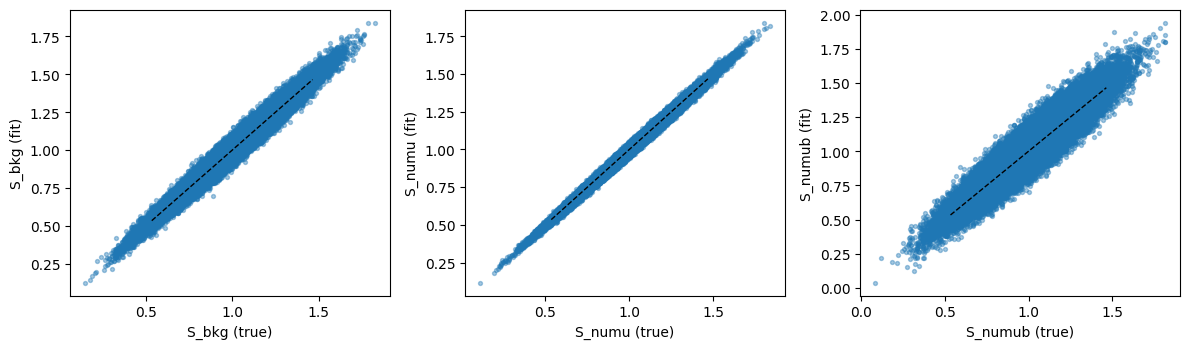

In [ ]:
# (B) Fit vs True (should lie along y=x on average)
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(true_S[:,k], fit_S[:,k], s=8, alpha=0.4)
    tmin, tmax = np.percentile(true_S[:,k], [1, 99])
    x = np.linspace(tmin, tmax, 100)
    ax.plot(x, x, 'k--', lw=1)  # ideal line
    ax.set_xlabel(f"{name} (true)")
    ax.set_ylabel(f"{name} (fit)")
plt.show()

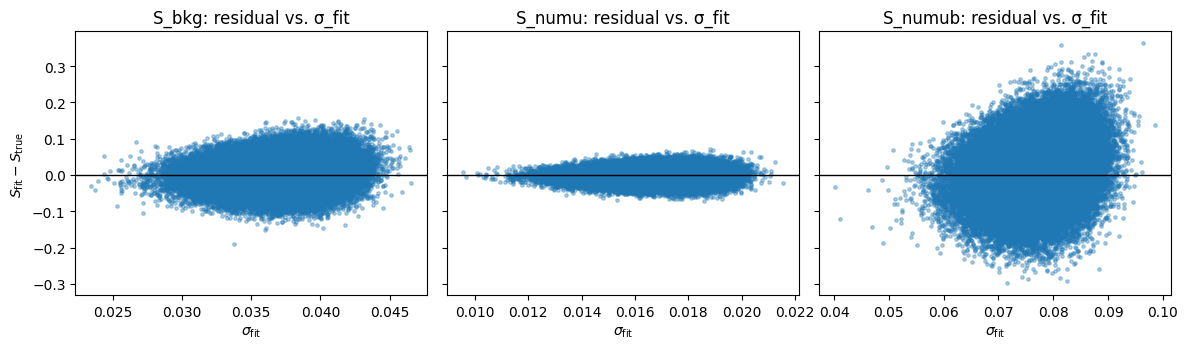

In [ ]:
# (C) Residual vs sigma_fit
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True, sharey=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(fit_err[:,k], fit_S[:,k] - true_S[:,k], s=6, alpha=0.35)
    ax.axhline(0, color='k', lw=1)
    ax.set_xlabel(rf"$\sigma_{{\rm fit}}$")
    ax.set_title(f"{name}: residual vs. σ_fit")
axes[0].set_ylabel(r"$S_{\rm fit}-S_{\rm true}$")
plt.show()

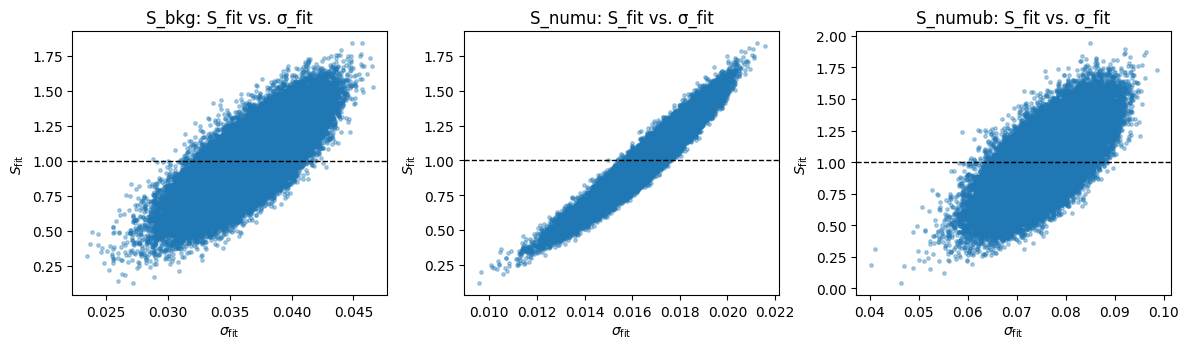

In [ ]:
# (D) S_fit vs sigma_fit
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(fit_err[:,k], fit_S[:,k], s=6, alpha=0.35)
    ax.axhline(1.0, color='k', lw=1, ls='--')   # mean of the Gaussian draw
    ax.set_xlabel(rf"$\sigma_{{\rm fit}}$")
    ax.set_ylabel(rf"$S_{{\rm fit}}$")
    ax.set_title(f"{name}: S_fit vs. σ_fit")
plt.show()

## NOW, same but for the numubarCC score, ranging 0 to 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# -----------------------
# 0) Templates from df_mcFC_FHC
# -----------------------
score = df_mcFC_FHC["bdt_score_numubarcc"].to_numpy()
w_nom = df_mcFC_FHC["weight_ubtune"].to_numpy()

mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_bkg   = ~(mask_numu | mask_numub)

bins = np.linspace(0, 1, 50)
bin_centers = 0.5*(bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

T_bkg,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_nom[mask_bkg])
T_numu,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_nom[mask_numu])
T_numub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_nom[mask_numub])

# -----------------------
# 1) Toy configuration
# -----------------------
N_toys = 100000
rng    = np.random.default_rng(20250929)
sig_draw = np.array([0.20, 0.20, 0.20])

true_S  = np.zeros((N_toys, 3))
fit_S   = np.zeros((N_toys, 3))
fit_err = np.zeros((N_toys, 3))
pulls   = np.zeros((N_toys, 3))
chi2ndf = np.zeros(N_toys)

pars = ("S_bkg", "S_numu", "S_numub")
names = ["S_bkg", "S_numu", "S_numub"]

# choose which toy to save for display
toy_to_plot = 0
saved_toy = None

# -----------------------
# 2) Run toys
# -----------------------
for i in range(N_toys):
    S_true = rng.normal(loc=1.0, scale=sig_draw, size=3)
    S_true = np.clip(S_true, 0.0, None)
    true_S[i] = S_true

    mu  = S_true[0]*T_bkg + S_true[1]*T_numu + S_true[2]*T_numub
    toy = rng.poisson(lam=np.maximum(mu, 0.0))
    yerr = np.sqrt(np.maximum(toy, 1.0))

    def chi2(S_bkg, S_numu, S_numub):
        model = S_bkg*T_bkg + S_numu*T_numu + S_numub*T_numub
        return np.sum(((toy - model)/yerr)**2)

    m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
    m.limits = [(0, None), (0, None), (0, None)]
    m.errordef = Minuit.LEAST_SQUARES
    m.migrad()
    m.hesse()

    fit_raw = np.array([m.values[p] for p in pars])
    err_raw = np.array([m.errors[p] for p in pars])

    fit_S[i, :]   = fit_raw
    fit_err[i, :] = err_raw

    for k in range(3):
        sigma = err_raw[k]
        pulls[i, k] = (fit_raw[k] - S_true[k]) / (sigma if sigma > 0 else np.nan)

    ndf = len(toy) - 3
    chi2ndf[i] = m.fval / ndf

    if i == toy_to_plot:
        best_bkg   = m.values["S_bkg"]   * T_bkg
        best_numu  = m.values["S_numu"]  * T_numu
        best_numub = m.values["S_numub"] * T_numub
        best_total = best_bkg + best_numu + best_numub

        saved_toy = {
            "toy": toy.copy(),
            "yerr": yerr.copy(),
            "S_true": S_true.copy(),
            "S_fit": fit_raw.copy(),
            "S_err": err_raw.copy(),
            "best_bkg": best_bkg.copy(),
            "best_numu": best_numu.copy(),
            "best_numub": best_numub.copy(),
            "best_total": best_total.copy(),
            "chi2ndf": m.fval / ndf
        }

for j, name in enumerate(names):
    print(f"{name}: mean={np.nanmean(pulls[:,j]):+.5f}, width={np.nanstd(pulls[:,j]):.5f}")

print(f"chi2/ndf: mean = {np.mean(chi2ndf):.3f}, std = {np.std(chi2ndf):.3f}")


S_bkg: mean=+0.00342, width=1.01189
S_numu: mean=-0.02542, width=1.01411
S_numub: mean=-0.38555, width=1.04144
chi2/ndf: mean = 0.975, std = 0.208


In [ ]:
names = ["S_bkg","S_numu","S_numub"]
for k, name in enumerate(names):
    mean_pull = np.nanmean(pulls[:,k])
    width_pull = np.nanstd(pulls[:,k])
    print(f"{name}: mean pull = {mean_pull:+.3f}, width = {width_pull:.3f}  (N={np.isfinite(pulls[:,k]).sum()})")

print(f"chi2/ndf: mean = {np.mean(chi2ndf):.3f}, std = {np.std(chi2ndf):.3f}")

S_bkg: mean pull = +0.003, width = 1.012  (N=100000)
S_numu: mean pull = -0.025, width = 1.014  (N=100000)
S_numub: mean pull = -0.386, width = 1.041  (N=100000)
chi2/ndf: mean = 0.975, std = 0.208


In [ ]:
print("\n=== Summary: Bias and Resolution ===")
for k, name in enumerate(["S_bkg", "S_numu", "S_numub"]):
    diff = fit_S[:, k] - true_S[:, k]
    mean_diff = np.mean(diff)
    rms_diff  = np.std(diff)
    mean_sigma = np.mean(fit_err[:, k])
    coeff = np.polyfit(true_S[:,k], fit_S[:,k], deg=1)
    slope, intercept = coeff[0], coeff[1]
    print(f"{name}: mean diff = {mean_diff:+.4e}, RMS = {rms_diff:.4e}, <σ_fit> = {mean_sigma:.4e}, slope = {slope:.4f}, intercept = {intercept:+.4e}")



=== Summary: Bias and Resolution ===
S_bkg: mean diff = +8.6201e-04, RMS = 1.2615e-01, <σ_fit> = 1.2446e-01, slope = 0.9957, intercept = +5.1916e-03
S_numu: mean diff = -1.1296e-03, RMS = 4.2787e-02, <σ_fit> = 4.2123e-02, slope = 1.0005, intercept = -1.6062e-03
S_numub: mean diff = -3.0370e-02, RMS = 8.5861e-02, <σ_fit> = 8.3126e-02, slope = 1.0011, intercept = -3.1475e-02


In [ ]:
print("\n=== Mean fitted S_i across all toys ===")
for k, name in enumerate(names):
    mean_val = np.mean(fit_S[:, k])
    std_val  = np.std(fit_S[:, k])
    mean_true = np.mean(true_S[:, k]) if 'true_S' in locals() else 1.0
    print(f"{name}: ⟨S_fit⟩ = {mean_val:.4f} ± {std_val:.4f}   (⟨S_true⟩ = {mean_true:.4f})")



=== Mean fitted S_i across all toys ===
S_bkg: ⟨S_fit⟩ = 1.0006 ± 0.2355   (⟨S_true⟩ = 0.9998)
S_numu: ⟨S_fit⟩ = 0.9989 ± 0.2044   (⟨S_true⟩ = 1.0000)
S_numub: ⟨S_fit⟩ = 0.9692 ± 0.2184   (⟨S_true⟩ = 0.9995)


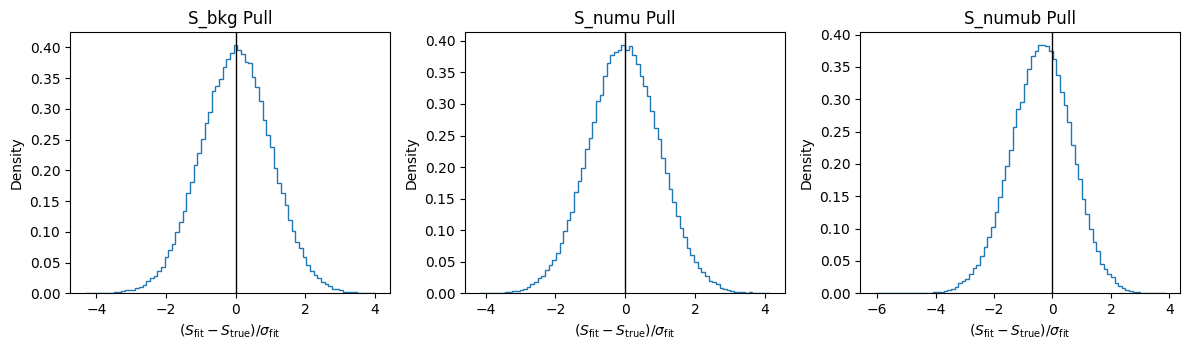

In [ ]:
# (A) Pull histograms
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.hist(pulls[:,k][np.isfinite(pulls[:,k])], bins=80, histtype='step', density=True)
    ax.axvline(0, color='k', lw=1)
    ax.set_title(f"{name} Pull")
    ax.set_xlabel(r"$(S_{\rm fit}-S_{\rm true})/\sigma_{\rm fit}$")
    ax.set_ylabel("Density")
plt.show()

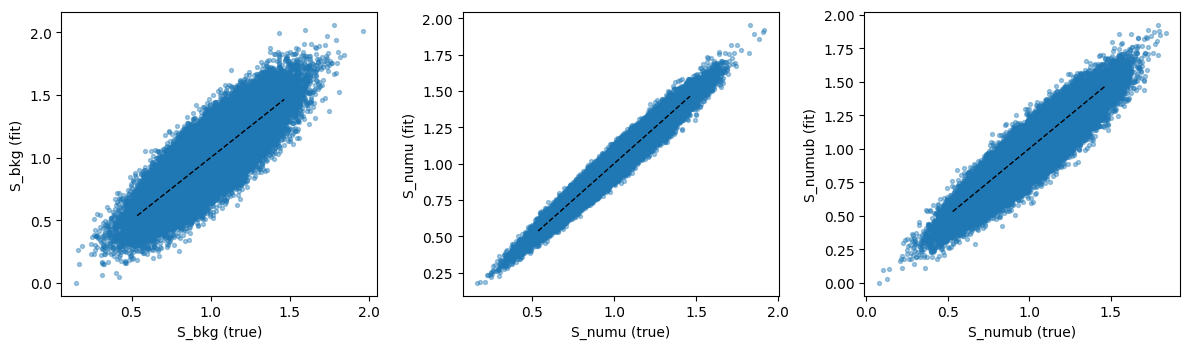

In [ ]:
# (B) Fit vs True
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(true_S[:,k], fit_S[:,k], s=8, alpha=0.4)
    tmin, tmax = np.percentile(true_S[:,k], [1, 99])
    x = np.linspace(tmin, tmax, 100)
    ax.plot(x, x, 'k--', lw=1)
    ax.set_xlabel(f"{name} (true)")
    ax.set_ylabel(f"{name} (fit)")
plt.show()

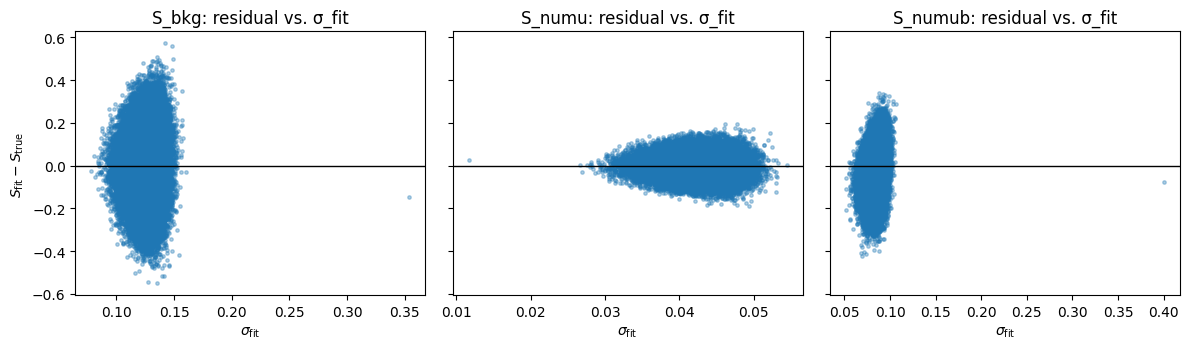

In [ ]:
# (C) Residual vs sigma_fit
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True, sharey=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(fit_err[:,k], fit_S[:,k] - true_S[:,k], s=6, alpha=0.35)
    ax.axhline(0, color='k', lw=1)
    ax.set_xlabel(rf"$\sigma_{{\rm fit}}$")
    ax.set_title(f"{name}: residual vs. σ_fit")
axes[0].set_ylabel(r"$S_{\rm fit}-S_{\rm true}$")
plt.show()

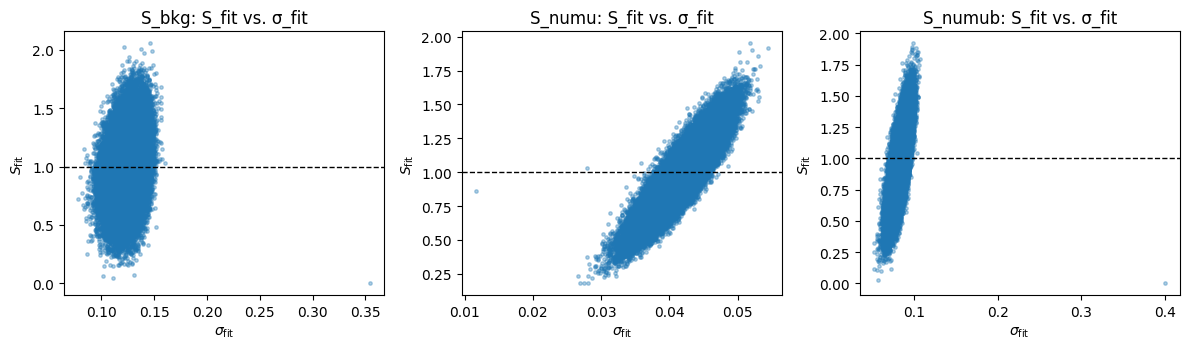

In [ ]:
# (D) S_fit vs sigma_fit
fig, axes = plt.subplots(1, 3, figsize=(12,3.6), tight_layout=True)
for ax, k, name in zip(axes, range(3), names):
    ax.scatter(fit_err[:,k], fit_S[:,k], s=6, alpha=0.35)
    ax.axhline(1.0, color='k', lw=1, ls='--')
    ax.set_xlabel(rf"$\sigma_{{\rm fit}}$")
    ax.set_ylabel(rf"$S_{{\rm fit}}$")
    ax.set_title(f"{name}: S_fit vs. σ_fit")
plt.show()

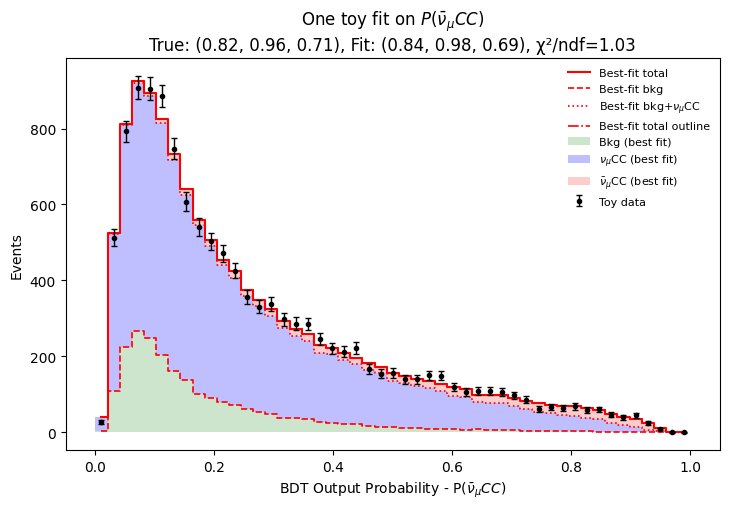

In [ ]:
toy = saved_toy["toy"]
yerr = saved_toy["yerr"]

best_bkg   = saved_toy["best_bkg"]
best_numu  = saved_toy["best_numu"]
best_numub = saved_toy["best_numub"]
best_total = saved_toy["best_total"]

plt.figure(figsize=(7.4, 5.2))

# stacked fitted components
plt.bar(bin_centers, best_bkg, width=bin_widths, color='green', alpha=0.20,
        label='Bkg (best fit)', align='center')
plt.bar(bin_centers, best_numu, width=bin_widths, bottom=best_bkg,
        color='blue', alpha=0.25, label=r'$\nu_\mu$CC (best fit)', align='center')
plt.bar(bin_centers, best_numub, width=bin_widths, bottom=best_bkg + best_numu,
        color='red', alpha=0.20, label=r'$\bar{\nu}_\mu$CC (best fit)', align='center')

# best-fit outlines
plt.step(bin_centers, best_total, where='mid', color='red', lw=1.5, label='Best-fit total')
plt.step(bin_centers, best_bkg, where='mid', color='red', lw=1.2, ls='--', label='Best-fit bkg')
plt.step(bin_centers, best_bkg + best_numu, where='mid', color='red', lw=1.2, ls=':', label=r'Best-fit bkg+$\nu_\mu$CC')
plt.step(bin_centers, best_total, where='mid', color='red', lw=1.2, ls='-.', label=r'Best-fit total outline')

# toy data
plt.errorbar(bin_centers, toy, yerr=yerr, fmt='o', color='black',
             markersize=3, lw=1, capsize=2, label='Toy data')

plt.xlabel(r'BDT Output Probability - P($\bar{\nu}_{\mu}CC$)')
plt.ylabel('Events')
plt.title(
    'One toy fit on $P(\\bar{\\nu}_{\\mu}CC)$\n'
    f'True: ({saved_toy["S_true"][0]:.2f}, {saved_toy["S_true"][1]:.2f}, {saved_toy["S_true"][2]:.2f}), '
    f'Fit: ({saved_toy["S_fit"][0]:.2f}, {saved_toy["S_fit"][1]:.2f}, {saved_toy["S_fit"][2]:.2f}), '
    f'χ²/ndf={saved_toy["chi2ndf"]:.2f}'
)
plt.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Replot the "weight_no_ubtune" after calibration


Raw (ubtune-template) fit:
  S_bkg = 0.9729 ± 0.0096
  S_numu = 0.8900 ± 0.0043
  S_numub = 0.9193 ± 0.0193
chi2/ndf = 29.33 / 46 = 0.64

Calibrated (mean-pull & width only; no linearity):
  S_bkg = 0.9761 ± 0.0098
  S_numu = 0.8897 ± 0.0043
  S_numub = 0.9280 ± 0.0202


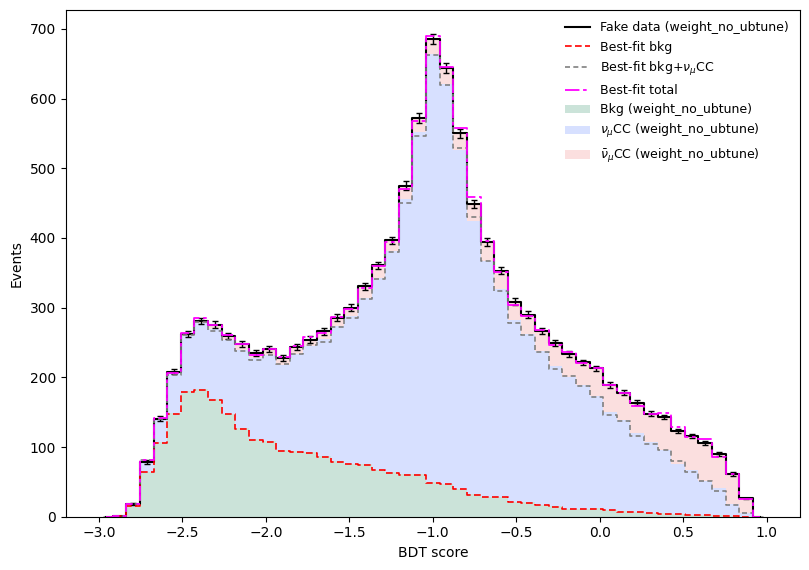

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# -----------------------
# Inputs from df_mc
# -----------------------
score = df_mcFC_FHC["bdt_score"].to_numpy()
w_ub   = df_mcFC_FHC["weight_ubtune"].to_numpy()      # templates used in fit (MODEL)
w_no   = df_mcFC_FHC["weight_no_ubtune"].to_numpy()   # stacked bars + "data"

mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_bkg   = ~(mask_numu | mask_numub)

bins        = np.linspace(-3, 1, 50)
bin_centers = 0.5*(bins[1:]+bins[:-1])
bin_widths  = np.diff(bins)

# -----------------------
# Templates for the MODEL (ubtune)  -> used in chi2
# -----------------------
T_bkg_ub,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_ub[mask_bkg])
T_numu_ub,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_ub[mask_numu])
T_numub_ub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_ub[mask_numub])

# -----------------------
# What we PLOT in the background (no_ubtune) and use as "data"
# -----------------------
T_bkg_no,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_no[mask_bkg])
T_numu_no,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_no[mask_numu])
T_numub_no, _ = np.histogram(score[mask_numub], bins=bins, weights=w_no[mask_numub])

data_hist, _ = np.histogram(score, bins=bins, weights=w_no)
data_var,  _ = np.histogram(score, bins=bins, weights=w_no**2)   # sum w^2 per bin
yerr = np.sqrt(np.maximum(data_var, 1e-12))

# -----------------------
# Fit: model = S_bkg*T_bkg_ub + S_numu*T_numu_ub + S_numub*T_numub_ub
# -----------------------
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg*T_bkg_ub + S_numu*T_numu_ub + S_numub*T_numub_ub
    return np.sum(((data_hist - model)/np.maximum(yerr, 1e-12))**2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits   = [(0,None),(0,None),(0,None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad(); m.hesse()

# -----------------------
# Calibration (mean-pull + width only; NO linearity)
#   sigma_corr = w * sigma_fit
#   S_corr     = S_fit - mu * sigma_corr
# -----------------------
cal = {
    "S_bkg":   dict(mean_pull=-0.327, width=1.023),
    "S_numu":  dict(mean_pull=+0.066, width=1.013),
    "S_numub": dict(mean_pull=-0.434, width=1.048),
}
pars   = ("S_bkg","S_numu","S_numub")
S_fit  = np.array([m.values[p] for p in pars])
S_err  = np.array([m.errors[p] for p in pars])
w_vec  = np.array([cal[p]["width"]     for p in pars])
mu_vec = np.array([cal[p]["mean_pull"] for p in pars])

sigma_corr = w_vec * S_err
S_corr     = S_fit - mu_vec * sigma_corr

# Build CALIBRATED stacked components (ubtune templates)
best_bkg_cal   = S_corr[0]*T_bkg_ub
best_numu_cal  = S_corr[1]*T_numu_ub
best_numub_cal = S_corr[2]*T_numub_ub
best_total_cal = best_bkg_cal + best_numu_cal + best_numub_cal

# -----------------------
# Print results
# -----------------------
ndf = len(data_hist) - 3
print("\nRaw (ubtune-template) fit:")
for p, v, e in zip(pars, S_fit, S_err):
    print(f"  {p} = {v:.4f} ± {e:.4f}")
print(f"chi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

print("\nCalibrated (mean-pull & width only; no linearity):")
for p, v, e in zip(pars, S_corr, sigma_corr):
    print(f"  {p} = {v:.4f} ± {e:.4f}")

# -----------------------
# Plot: bars = no_ubtune; dotted STACKED cumulatives = calibrated ubtune fit
# -----------------------
plt.figure(figsize=(8.2,5.8))

# Solid stacked background (no_ubtune)
plt.bar(bins[:-1], T_bkg_no,   width=bin_widths, color="#6BAF92", alpha=0.35,
        align="edge", edgecolor="none", label="Bkg (weight_no_ubtune)")
plt.bar(bins[:-1], T_numu_no,  width=bin_widths, bottom=T_bkg_no,
        color="#8DA7FF", alpha=0.35, align="edge", edgecolor="none",
        label=r"$\nu_\mu$CC (weight_no_ubtune)")
plt.bar(bins[:-1], T_numub_no, width=bin_widths, bottom=T_bkg_no+T_numu_no,
        color="#F4A6A6", alpha=0.35, align="edge", edgecolor="none",
        label=r"$\bar{\nu}_\mu$CC (weight_no_ubtune)")

# “Data” and errors (from no_ubtune)
plt.step(bin_centers, data_hist, where="mid", color="k", lw=1.5, label="Fake data (weight_no_ubtune)")
plt.errorbar(bin_centers, data_hist, yerr=yerr, fmt="none", ecolor="k", elinewidth=1, capsize=2)

# Dotted STACKED cumulatives (calibrated ubtune fit)
plt.step(bin_centers, best_bkg_cal,              where="mid", color="red",     lw=1.2, ls="--", dashes=(4,2),
         label="Best-fit bkg")
plt.step(bin_centers, best_bkg_cal+best_numu_cal,where="mid", color="gray",    lw=1.2, ls="--", dashes=(3,2),
         label=r"Best-fit bkg+$\nu_\mu$CC")
plt.step(bin_centers, best_total_cal,            where="mid", color="magenta", lw=1.3, ls="--", dashes=(8,2,2,2),
         label="Best-fit total")

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend(frameon=False, fontsize=9, ncols=1)
plt.tight_layout()
plt.show()


Pre-calibration


Raw (ubtune-template) fit (NON-CALIBRATED):
  S_bkg = 0.9729 ± 0.0096
  S_numu = 0.8900 ± 0.0043
  S_numub = 0.9193 ± 0.0193
chi2/ndf = 29.33 / 46 = 0.64


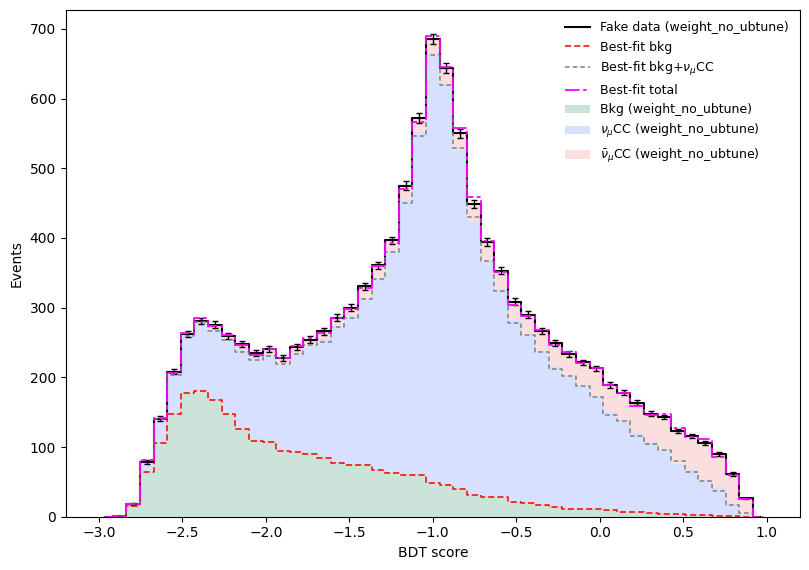

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# -----------------------
# Inputs from df_mc
# -----------------------
score = df_mcFC_FHC["bdt_score"].to_numpy()
w_ub   = df_mcFC_FHC["weight_ubtune"].to_numpy()      # -> templates used in fit (model)
w_no   = df_mcFC_FHC["weight_no_ubtune"].to_numpy()   # -> stacked bars + "data"

mask_numub = ((df_mcFC_FHC['truth_nuPdg'] == -14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_numu  = ((df_mcFC_FHC['truth_nuPdg'] ==  14) & (df_mcFC_FHC['truth_isCC'] == 1)).to_numpy()
mask_bkg   = ~(mask_numu | mask_numub)

bins        = np.linspace(-3, 1, 50)
bin_centers = 0.5*(bins[1:]+bins[:-1])
bin_widths  = np.diff(bins)

# -----------------------
# Templates for the MODEL (ubtune)  -> used in chi2
# -----------------------
T_bkg_ub,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_ub[mask_bkg])
T_numu_ub,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_ub[mask_numu])
T_numub_ub, _ = np.histogram(score[mask_numub], bins=bins, weights=w_ub[mask_numub])

# -----------------------
# What we PLOT in the background (no_ubtune) and use as "data"
# -----------------------
T_bkg_no,   _ = np.histogram(score[mask_bkg],   bins=bins, weights=w_no[mask_bkg])
T_numu_no,  _ = np.histogram(score[mask_numu],  bins=bins, weights=w_no[mask_numu])
T_numub_no, _ = np.histogram(score[mask_numub], bins=bins, weights=w_no[mask_numub])

data_hist, _ = np.histogram(score, bins=bins, weights=w_no)
data_var,  _ = np.histogram(score, bins=bins, weights=w_no**2)
yerr = np.sqrt(np.maximum(data_var, 1e-12))

# -----------------------
# Fit: model = S_bkg*T_bkg_ub + S_numu*T_numu_ub + S_numub*T_numub_ub
# -----------------------
def chi2(S_bkg, S_numu, S_numub):
    model = S_bkg*T_bkg_ub + S_numu*T_numu_ub + S_numub*T_numub_ub
    return np.sum(((data_hist - model)/np.maximum(yerr, 1e-12))**2)

m = Minuit(chi2, S_bkg=1.0, S_numu=1.0, S_numub=1.0)
m.limits   = [(0,None),(0,None),(0,None)]
m.errordef = Minuit.LEAST_SQUARES
m.migrad(); m.hesse()

# -----------------------
# NON-CALIBRATED results
# -----------------------
pars  = ("S_bkg","S_numu","S_numub")
S_fit = np.array([m.values[p] for p in pars])
S_err = np.array([m.errors[p] for p in pars])

# Build NON-CALIBRATED model curves (stacked for clarity)
best_bkg   = S_fit[0]*T_bkg_ub
best_numu  = S_fit[1]*T_numu_ub
best_numub = S_fit[2]*T_numub_ub
best_total = best_bkg + best_numu + best_numub

# -----------------------
# Print results
# -----------------------
ndf = len(data_hist) - 3
print("\nRaw (ubtune-template) fit (NON-CALIBRATED):")
for p, v, e in zip(pars, S_fit, S_err):
    print(f"  {p} = {v:.4f} ± {e:.4f}")
print(f"chi2/ndf = {m.fval:.2f} / {ndf} = {m.fval/ndf:.2f}")

# -----------------------
# Plot: bars = no_ubtune; dotted stacked fit = ubtune fit
# -----------------------
plt.figure(figsize=(8.2,5.8))

# --- Solid background: no_ubtune (the “truth/fake data”) ---
plt.bar(bins[:-1], T_bkg_no,   width=bin_widths, color="#6BAF92", alpha=0.35,
        align="edge", edgecolor="none", label="Bkg (weight_no_ubtune)")
plt.bar(bins[:-1], T_numu_no,  width=bin_widths, bottom=T_bkg_no,
        color="#8DA7FF", alpha=0.35, align="edge", edgecolor="none",
        label=r"$\nu_\mu$CC (weight_no_ubtune)")
plt.bar(bins[:-1], T_numub_no, width=bin_widths, bottom=T_bkg_no+T_numu_no,
        color="#F4A6A6", alpha=0.35, align="edge", edgecolor="none",
        label=r"$\bar{\nu}_\mu$CC (weight_no_ubtune)")

# --- “Data” line ---
plt.step(bin_centers, data_hist, where="mid", color="k", lw=1.5, label="Fake data (weight_no_ubtune)")
plt.errorbar(bin_centers, data_hist, yerr=yerr, fmt="none", ecolor="k", elinewidth=1, capsize=2)

# --- Dotted stacked lines from ubtune templates * fitted scales ---
plt.step(bin_centers, best_bkg, where="mid", color="red", lw=1.1, ls="--", dashes=(4,2), label="Best-fit bkg")
plt.step(bin_centers, best_bkg+best_numu, where="mid", color="gray", lw=1.1, ls="--", dashes=(3,2),
         label=r"Best-fit bkg+$\nu_\mu$CC")
plt.step(bin_centers, best_total, where="mid", color="magenta", lw=1.3, ls="--", dashes=(8,2,2,2),
         label="Best-fit total")

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend(frameon=False, fontsize=9, ncols=1)
plt.tight_layout()
plt.show()


## Try to constrain the background and look at the Neutral current things